# 📈 Stock Price Prediction — Целосен ML Проект
### Предвидување на цените на акции со машинско учење и временски серии
---
**Структура на Проектот:**
1. 📦 Вчитување и прва инспекција на датасетот
2. 🔍 Длабока EDA (Exploratory Data Analysis)
3. 🚨 Детекција и обработка на Outliers (IQR + Z-Score)
4. ⚙️ Preprocessing — Window Size, Feature Engineering, Скалирање
5. 📊 Корелациска анализа
6. ✂️ Train/Test Split (хронолошки)
7. 🤖 Тренирање на ML Модели (RF, KNN, SVM, XGBoost)
8. 📉 Временска Серија — ARIMA
9. 🧠 Длабоко учење — LSTM
10. 🏆 Евалуација и споредба на сите модели
11. 🔮 Детална анализа на Јануари 2024

## 📦 1. Вчитување на библиотеки

In [44]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import time

# Поставување на фиксиран seed за реплицираност на резултатите
import random
def set_all_seeds(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Дополнителна библиотека за динамично преземање податоци од берза
# Напомена: Ако ја немате инсталирано, извршете: !pip install yfinance
import yfinance as yf 

# ML модели
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Временска серија — ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Длабоко учење — LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Активирај го семето веднаш
set_all_seeds(42)

# Визуелен стил
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("tab10")

print("✅ Сите библиотеки се успешно вчитани.")
print(f"   TensorFlow верзија: {tf.__version__}")   
print(f"   NumPy верзија:      {np.__version__}")
print(f"   Pandas верзија:     {pd.__version__}")
print(f"   yfinance верзија:   {yf.__version__}")

✅ Сите библиотеки се успешно вчитани.
   TensorFlow верзија: 2.21.0
   NumPy верзија:      2.3.4
   Pandas верзија:     2.3.3
   yfinance верзија:   1.4.1


## 📂 2. Вчитување и прва инспекција на датасетот

In [45]:
# 1. Дефинирање на точните релативни патеки
base_dir = os.getcwd()
stocks_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_stocks.csv')
index_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_index.csv')
companies_path = os.path.join(base_dir, '..', 'data', 'raw', 'sp500_companies.csv')

# 2. Вчитување на точните фајлови во точните варијабли
df_stocks_raw = pd.read_csv(stocks_path)
df_index_raw = pd.read_csv(index_path)
df_companies_raw = pd.read_csv(companies_path)

print("✅ Сите три CSV фајлови се успешно вчитани во меморијата.")

✅ Сите три CSV фајлови се успешно вчитани во меморијата.


Инспекција на sp500_companies.csv

In [46]:
print("=== ИНСПЕКЦИЈА НА COMPANIES ДАТАСЕТОТ ===")
print(f"Димензии: {df_companies_raw.shape[0]} компании и {df_companies_raw.shape[1]} мета-колони.\n")
print("Првите 3 реда од табелата:")
display(df_companies_raw.head(3))

print("\nКолони кои се достапни за компаниите:")
print(df_companies_raw.columns.tolist())

=== ИНСПЕКЦИЈА НА COMPANIES ДАТАСЕТОТ ===
Димензии: 502 компании и 16 мета-колони.

Првите 3 реда од табелата:


,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401



Колони кои се достапни за компаниите:
['Exchange', 'Symbol', 'Shortname', 'Longname', 'Sector', 'Industry', 'Currentprice', 'Marketcap', 'Ebitda', 'Revenuegrowth', 'City', 'State', 'Country', 'Fulltimeemployees', 'Longbusinesssummary', 'Weight']


Инспекција на sp500_index.csv

In [47]:
print("=== ИНСПЕКЦИЈА НА S&P 500 INDEX ДАТАСЕТОТ ===")
print(f"Димензии: {df_index_raw.shape[0]} работни денови на берзата.\n")
print("Првите 5 денови од историјата на индексот:")
display(df_index_raw.head(5))

# Статистички преглед на индексот
print("\nОсновна статистика за вредноста на индексот:")
display(df_index_raw.describe())

=== ИНСПЕКЦИЈА НА S&P 500 INDEX ДАТАСЕТОТ ===
Димензии: 2517 работни денови на берзата.

Првите 5 денови од историјата на индексот:


,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57



Основна статистика за вредноста на индексот:


,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


Инспекција на sp500_stocks.csv

In [48]:
print("=== ИНСПЕКЦИЈА НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===")
print(f"Вкупен број на записи за сите акции: {df_stocks_raw.shape[0]:,}")
print(f"Број на колони: {df_stocks_raw.shape[1]}\n")

print("🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:")
nan_counts = df_stocks_raw.isnull().sum()
display(nan_counts[nan_counts > 0])

print("\nПример од првите 5 редови во табелата:")
display(df_stocks_raw.head(5))

=== ИНСПЕКЦИЈА НА ГЛАВНИОТ STOCKS ДАТАСЕТ ===
Вкупен број на записи за сите акции: 1,891,536
Број на колони: 8

🔍 Детекција на недостапни (NaN) вредности во овој огромен фајл:


Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64


Пример од првите 5 редови во табелата:


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df_stocks_raw[df_stocks_raw['Close'].notna()]

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
3768,2010-01-04,AOS,5.937266,7.435000,7.480000,7.261667,7.295000,1104600.0
3769,2010-01-05,AOS,5.861404,7.340000,7.431667,7.308333,7.431667,1207200.0
3770,2010-01-06,AOS,5.864068,7.343333,7.405000,7.301667,7.335000,663000.0
3771,2010-01-07,AOS,5.881369,7.365000,7.425000,7.311667,7.356667,564000.0
3772,2010-01-08,AOS,5.967879,7.473333,7.485000,7.311667,7.331667,504600.0
...,...,...,...,...,...,...,...,...
1876459,2024-12-16,XYL,120.779999,120.779999,122.570000,120.000000,120.720001,1515900.0
1876460,2024-12-17,XYL,120.769997,120.769997,121.760002,119.730003,119.730003,2009200.0
1876461,2024-12-18,XYL,116.919998,116.919998,121.559998,116.879997,120.790001,1638500.0
1876462,2024-12-19,XYL,116.430000,116.430000,118.919998,116.129997,117.440002,1708000.0


Филтрирање и спојување на податоците 

🎉 Успешно креиран споениот сет податоци за TSLA!

  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2517 non-null   datetime64[ns]
 1   Symbol     2517 non-null   object        
 2   Adj Close  2517 non-null   float64       
 3   Close      2517 non-null   float64       
 4   High       2517 non-null   float64       
 5   Low        2517 non-null   float64       
 6   Open       2517 non-null   float64       
 7   Volume     2517 non-null   float64       
 8   S&P500     2517 non-null   float64       
 9   Longname   2517 non-null   object        
 10  Sector     2517 non-null   object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 216.4+ KB

  ПРЕОСТАНАТИ MISSING VALUES
✅ Нема missing values!

  ДЕСКРИПТИВНА СТАТИСТИКА


,Date,Adj Close,Close,High,Low,Open,Volume,S&P500
count,2517,2517.0000,2517.0000,2517.0000,2517.0000,2517.0000,2.517000e+03,2517.0000
mean,2019-12-22 08:34:53.921335040,114.6419,114.6419,117.1852,111.9709,114.6539,1.122236e+08,3346.3516
min,2014-12-22 00:00:00,9.5780,9.5780,10.3313,9.4033,9.4880,1.062000e+07,1829.0800
25%,2017-06-22 00:00:00,17.1273,17.1273,17.3967,16.8013,17.1200,6.676160e+07,2428.3700
50%,2019-12-20 00:00:00,26.9360,26.9360,27.1233,25.3720,25.9333,9.282970e+07,2999.9100
75%,2022-06-22 00:00:00,219.8000,219.8000,224.2600,214.8200,220.1300,1.297740e+08,4199.1200
max,2024-12-20 00:00:00,479.8600,479.8600,488.5400,457.5100,475.9000,9.140820e+08,6090.2700
std,NaN,113.2613,113.2613,115.8934,110.5351,113.3216,7.411270e+07,1078.2043


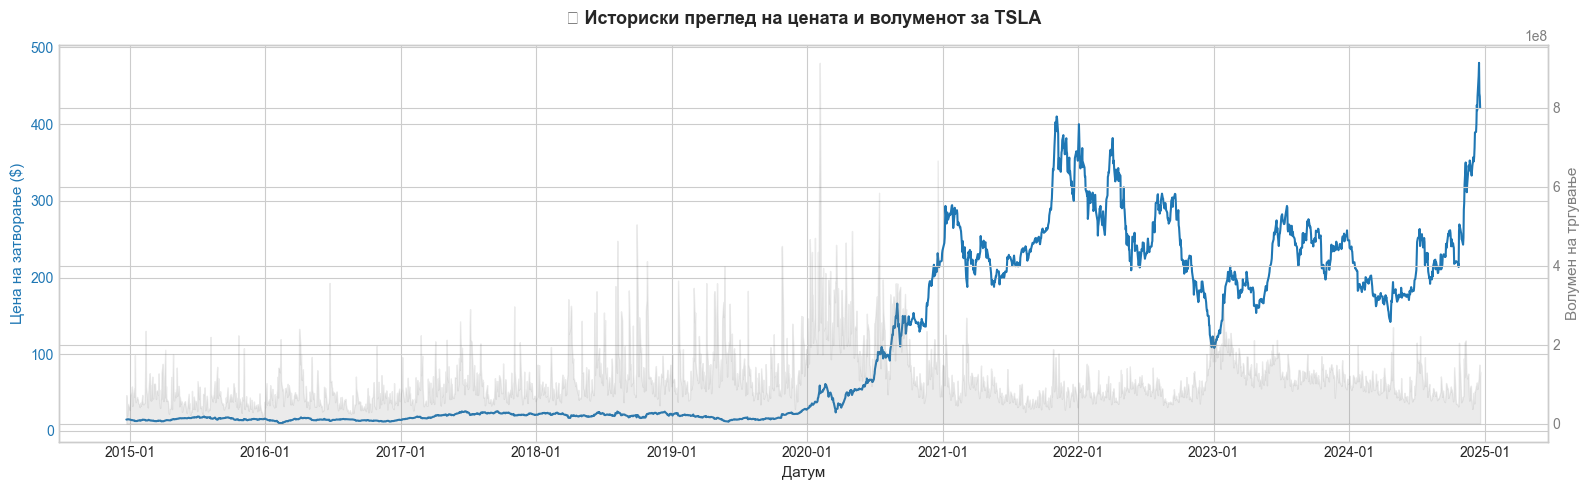

In [50]:
# =====================================================================
# 1. ПРВО КРЕИРАЊЕ НА ФИНАЛНАТА ТАБЕЛА (Филтрирање за Тесла и Мерџ на 3-те фајлови)
# =====================================================================
TICKER = 'TSLA'

# Чистење од празни места во колоните на главниот фајл
df_stocks_raw.columns = df_stocks_raw.columns.str.strip()
df_stocks_raw.dropna(subset=['Symbol'], inplace=True)
df_stocks_raw['Symbol'] = df_stocks_raw['Symbol'].astype(str).str.strip()

# Издвојување само на податоците за Тесла
df = df_stocks_raw[df_stocks_raw['Symbol'].str.upper() == TICKER.upper()].copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Тргање на денови каде што нема цена на затворање
df.dropna(subset=['Close'], inplace=True)

# А) Спојување со индексот (по Датум)
df_index_raw['Date'] = pd.to_datetime(df_index_raw['Date'])
df = pd.merge(df, df_index_raw, on='Date', how='left', suffixes=('', '_index'))

# Б) Спојување со метаподатоците за компаниите (по твоите точни колони: Symbol, Longname, Sector)
df_companies_raw['Symbol'] = df_companies_raw['Symbol'].astype(str).str.strip()
df = pd.merge(df, df_companies_raw[['Symbol', 'Longname', 'Sector']], on='Symbol', how='left')

# ✨ НАШАТА ПАМЕТНА КОРЕКЦИЈА: Ги бришеме деновите каде пазарниот индекс е празен (пред декември 2014)
df.dropna(subset=['S&P500'], inplace=True)

# Финално ресетирање на индексите по чистењето
df.reset_index(drop=True, inplace=True)

print(f"🎉 Успешно креиран споениот сет податоци за {TICKER}!\n")

# =====================================================================
# 2. ТВОЈОТ КОД ЗА ИНФОРМАЦИИ И ДЕСКРИПТИВНА СТАТИСТИКА
# =====================================================================
print("=" * 60)
print("  ИНФОРМАЦИИ ЗА ДАТАСЕТОТ")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("  ПРЕОСТАНАТИ MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Бројка': missing, 'Процент (%)': missing_pct})
print(missing_df[missing_df['Бројка'] > 0] if missing.sum() > 0 else "✅ Нема missing values!")

print("\n" + "=" * 60)
print("  ДЕСКРИПТИВНА СТАТИСТИКА")
print("=" * 60)
display(df.describe().round(4))

# =====================================================================
# 3. ТВОЈОТ КОД ЗА ВИЗУЕЛИЗАЦИЈА
# =====================================================================
fig, ax1 = plt.subplots(figsize=(16, 5))

# Прва оска за Close цената
color = 'tab:blue'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена на затворање ($)', color=color, fontsize=11)
ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Втора оска за Волуменот (со споделена х-оска)
ax2 = ax1.twinx()  
color = 'tab:gray'
ax2.set_ylabel('Волумен на тргување', color=color, fontsize=11)
ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.15, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f"📈 Историски преглед на цената и волуменот за {TICKER}", fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 🔍 3. Длабока EDA (Exploratory Data Analysis)



Историски тренд на цена и волумен

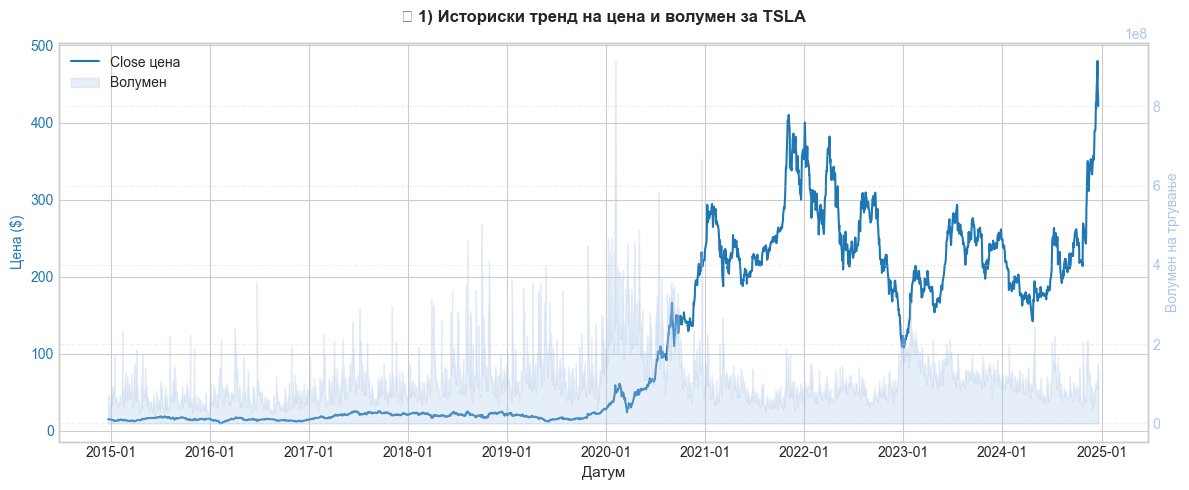

In [51]:

# Креирање на посебен график за цена и волумен
fig, ax1 = plt.subplots(figsize=(12, 5))

# Прва оска за сината линија (Close цена)
color = '#1f77b4'
ax1.set_xlabel('Датум', fontsize=11)
ax1.set_ylabel('Цена ($)', color=color)
p1, = ax1.plot(df['Date'], df['Close'], color=color, linewidth=1.5, label='Close цена')
ax1.tick_params(axis='y', labelcolor=color)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Втора оска (twinx) за светлосната сенка во позадина (Волумен)
ax2 = ax1.twinx()
color = '#aec7e8'
ax2.set_ylabel('Волумен на тргување', color=color)
p2 = ax2.fill_between(df['Date'], df['Volume'], color=color, alpha=0.3, label='Волумен')
ax2.tick_params(axis='y', labelcolor=color)

# Обединување на легендите во едно заедничко прозорче
ax1.legend([p1, p2], [p1.get_label(), p2.get_label()], loc='upper left', fontsize=10)

plt.title(f'📈 1) Историски тренд на цена и волумен за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Дистрибуција на цената (Хистограм)

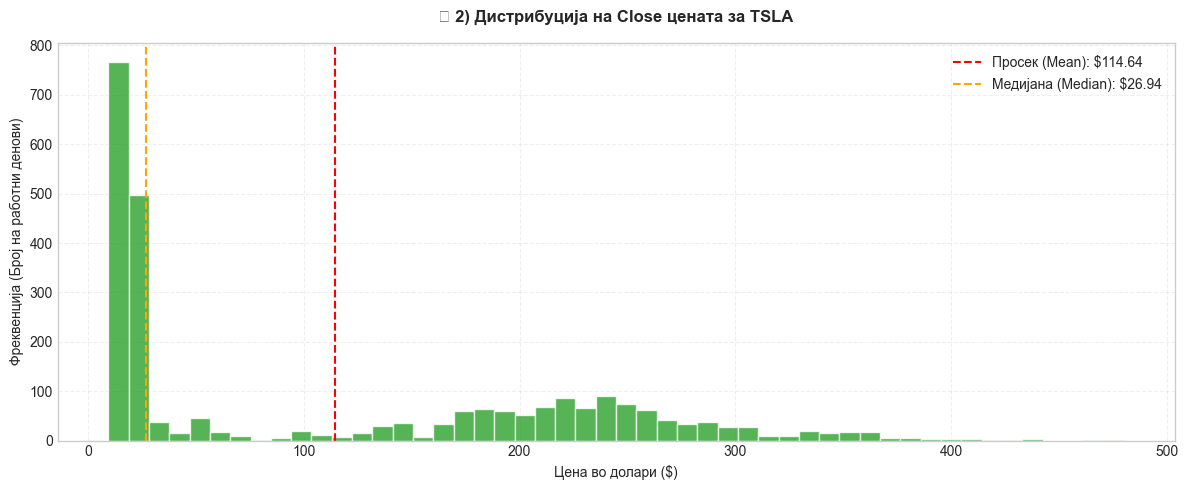

In [52]:
# Креирање график за дистрибуција (Хистограм)
plt.figure(figsize=(12, 5))

# Цртање на хистограмот со 50 колони (bins)
plt.hist(df['Close'], bins=50, color='#2ca02c', edgecolor='white', alpha=0.8)

# Додавање на црвена линија за Просекот и портокалова за Медијаната
plt.axvline(df['Close'].mean(), color='red', linestyle='--', linewidth=1.5, 
            label=f"Просек (Mean): ${df['Close'].mean():.2f}")
plt.axvline(df['Close'].median(), color='orange', linestyle='--', linewidth=1.5, 
            label=f"Медијана (Median): ${df['Close'].median():.2f}")

plt.title(f'📊 2) Дистрибуција на Close цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.legend(fontsize=10)
plt.xlabel('Цена во долари ($)')
plt.ylabel('Фреквенција (Број на работни денови)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Годишен просек на цената

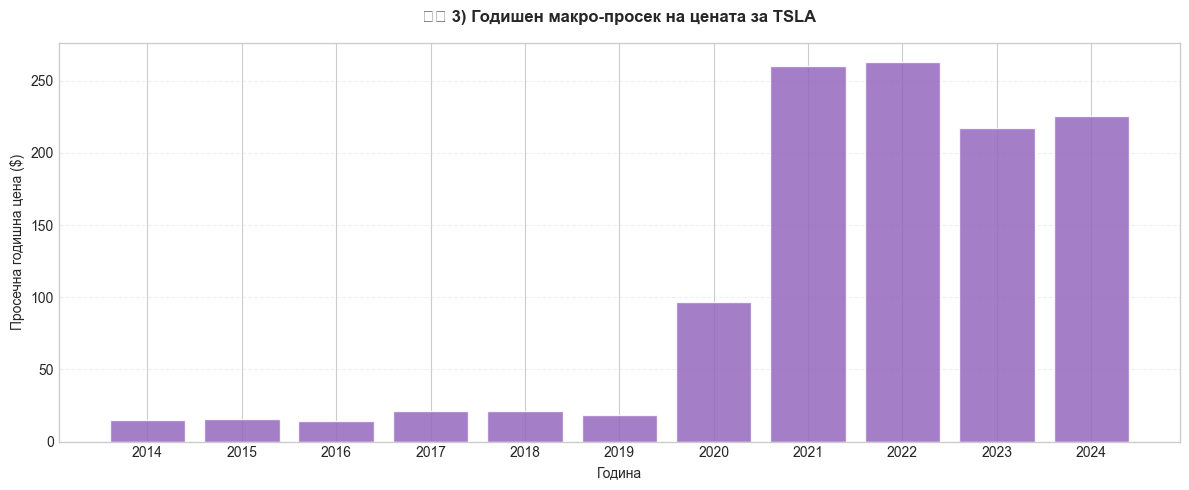

In [53]:
# Привремено извлекување на годината од датумот за групирање
df['Year'] = df['Date'].dt.year
yearly = df.groupby('Year')['Close'].mean()

# Креирање на столбест график
plt.figure(figsize=(12, 5))
plt.bar(yearly.index.astype(str), yearly.values, color='#9467bd', edgecolor='white', alpha=0.85)

plt.title(f'🏛️ 3) Годишен макро-просек на цената за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Година')
plt.ylabel('Просечна годишна цена ($)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Бришење на привремената колона за да не го валкаме датасетот
df.drop(columns=['Year'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Сезонски просек по месеци (Seasonality)

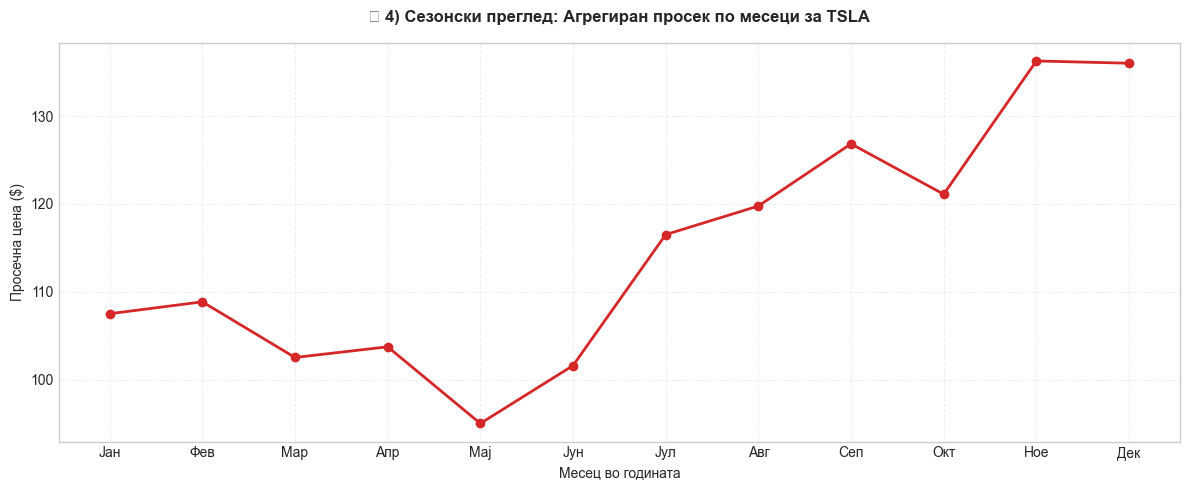

In [54]:
# Привремено извлекување на месецот
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['Close'].mean()
months_labels = ['Јан','Фев','Мар','Апр','Мај','Јун','Јул','Авг','Сеп','Окт','Ное','Дек']

# Креирање линиски график со точки за секој месец
plt.figure(figsize=(12, 5))
plt.plot(range(1, 13), monthly.values, marker='o', color='#d62728', linewidth=2, markersize=6)

plt.title(f'📅 4) Сезонски преглед: Агрегиран просек по месеци за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xticks(range(1, 13), months_labels, fontsize=10)
plt.xlabel('Месец во годината')
plt.ylabel('Просечна цена ($)')
plt.grid(True, linestyle='--', alpha=0.3)

# Финално чистење на помошната колона Month
df.drop(columns=['Month'], inplace=True, errors='ignore')

plt.tight_layout()
plt.show()

Пресметка на приноси

In [55]:
df['Daily_Return_Raw'] = df['Close'].pct_change()

# Подготовка на податоци во проценти (%) за подобра читливост на графиконите
returns_pct = df['Daily_Return_Raw'].dropna() * 100

print("✅ Дневните приноси се успешно пресметани!")

✅ Дневните приноси се успешно пресметани!


Дистрибуција на приноси

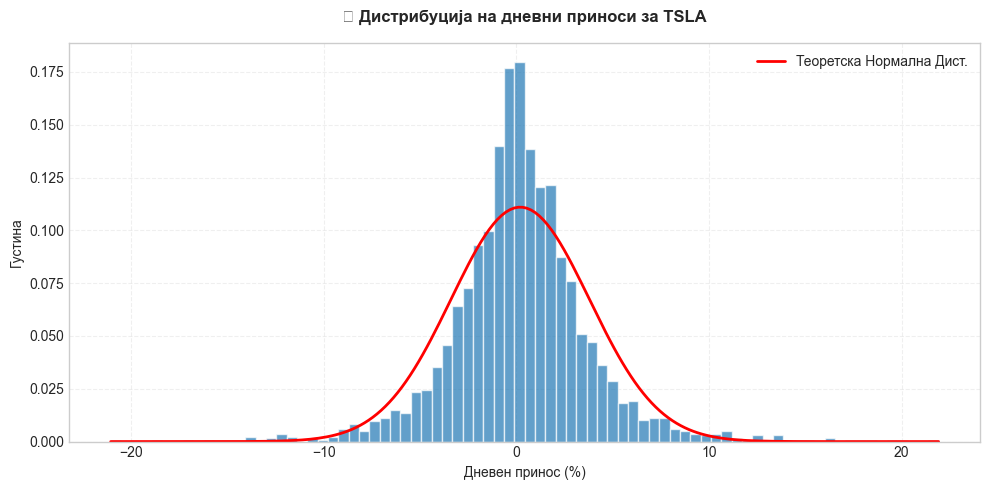

In [56]:
plt.figure(figsize=(10, 5))

# Цртање на реалниот хистограм (сините столбови)
plt.hist(returns_pct, bins=80, color='#1f77b4', edgecolor='white', alpha=0.7, density=True)

# Креирање на Црвената линија (Теоретска Нормална Дистрибуција)
mu_pct, sigma_pct = returns_pct.mean(), returns_pct.std()
x = np.linspace(returns_pct.min(), returns_pct.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu_pct, sigma_pct), 'r-', linewidth=2, label='Теоретска Нормална Дист.')

plt.title(f'📉 Дистрибуција на дневни приноси за {TICKER}', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Дневен принос (%)')
plt.ylabel('Густина')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Boxplot и Ролинг Волатилност

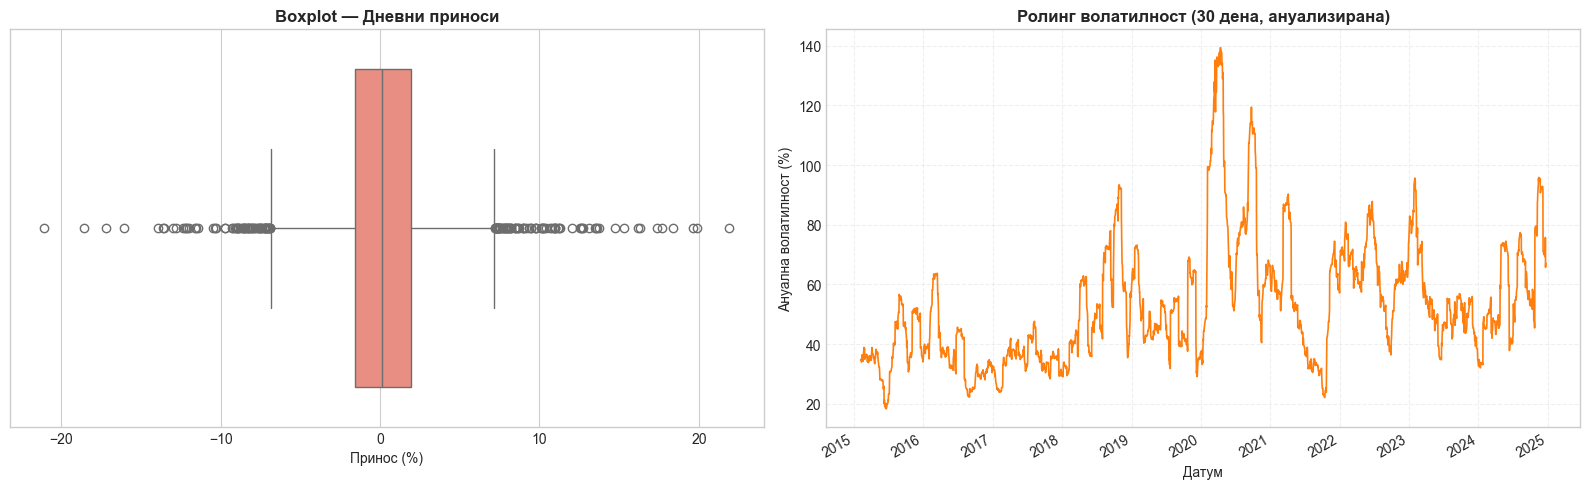

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot (Мерење на екстремни денови во проценти)
sns.boxplot(x=returns_pct, ax=ax1, color='salmon')
ax1.set_title('Boxplot — Дневни приноси', fontweight='bold')
ax1.set_xlabel('Принос (%)')

# 2. Ролинг волатилност (30 дена, ануализирана)
rolling_vol = df['Daily_Return_Raw'].rolling(30).std() * np.sqrt(252) * 100
ax2.plot(df['Date'], rolling_vol, color='#ff7f0e', linewidth=1.2, label='30д Ролинг Волатилност')
ax2.set_title('Ролинг волатилност (30 дена, ануализирана)', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('Ануална волатилност (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Статистички бројки и пополнување на дупки

In [58]:
# Пополнување на првиот ред (кој стана NaN бидејќи првиот ден нема претходен ден со кој би се споредил)
df['Daily_Return_Raw'] = df['Daily_Return_Raw'].fillna(0)

print(f"=" * 50)
print(f"📊 ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ")
print(f"=" * 50)
print(f"   Просечен дневен принос:  {mu_pct:.4f}%")
print(f"   Стандардна девијација:   {sigma_pct:.4f}%")
print(f"   Skewness (асиметрија):   {returns_pct.skew():.4f}")
print(f"   Kurtosis:     {returns_pct.kurtosis():.4f}")
print(f"=" * 50)

📊 ДЕСКРИПТИВНА СТАТИСТИКА НА ДНЕВНИТЕ ПРИНОСИ
   Просечен дневен принос:  0.1974%
   Стандардна девијација:   3.5948%
   Skewness (асиметрија):   0.2746
   Kurtosis:     4.4331


## 🚨 4. Детекција и обработка на Outliers

Математичка пресметка и детекција (IQR и Z-Score).


In [59]:
# Креираме привремена серија во проценти (%) за поконзистентен приказ
returns_pct = df['Daily_Return_Raw'] * 100

# ── 1) IQR Метод (Во проценти) ──
Q1 = returns_pct.quantile(0.25)
Q3 = returns_pct.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr_idx = (returns_pct < lower_iqr) | (returns_pct > upper_iqr)
outliers_iqr = df[outliers_iqr_idx]

# ── 2) Z-Score Метод (Врз основа на оригиналните приноси) ──
z_scores = np.abs(stats.zscore(df['Daily_Return_Raw']))
outliers_zscore = df[z_scores > 3]

print("=" * 60)
print(" 📊 РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS")
print("=" * 60)
print(f"IQR Метод       — Граници: [{lower_iqr:.2f}%, {upper_iqr:.2f}%]")
print(f"                — Пронајдени аутлаери: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"Z-Score (>3σ)  — Пронајдени аутлаери: {len(outliers_zscore)} ({len(outliers_zscore)/len(df)*100:.2f}%)")
print("=" * 60)

 📊 РЕЗУЛТАТИ ОД ДЕТЕКЦИЈА НА OUTLIERS
IQR Метод       — Граници: [-6.84%, 7.16%]
                — Пронајдени аутлаери: 151 (6.00%)
Z-Score (>3σ)  — Пронајдени аутлаери: 42 (1.67%)


Визуелизација на аномалиите (Scatter Plots)

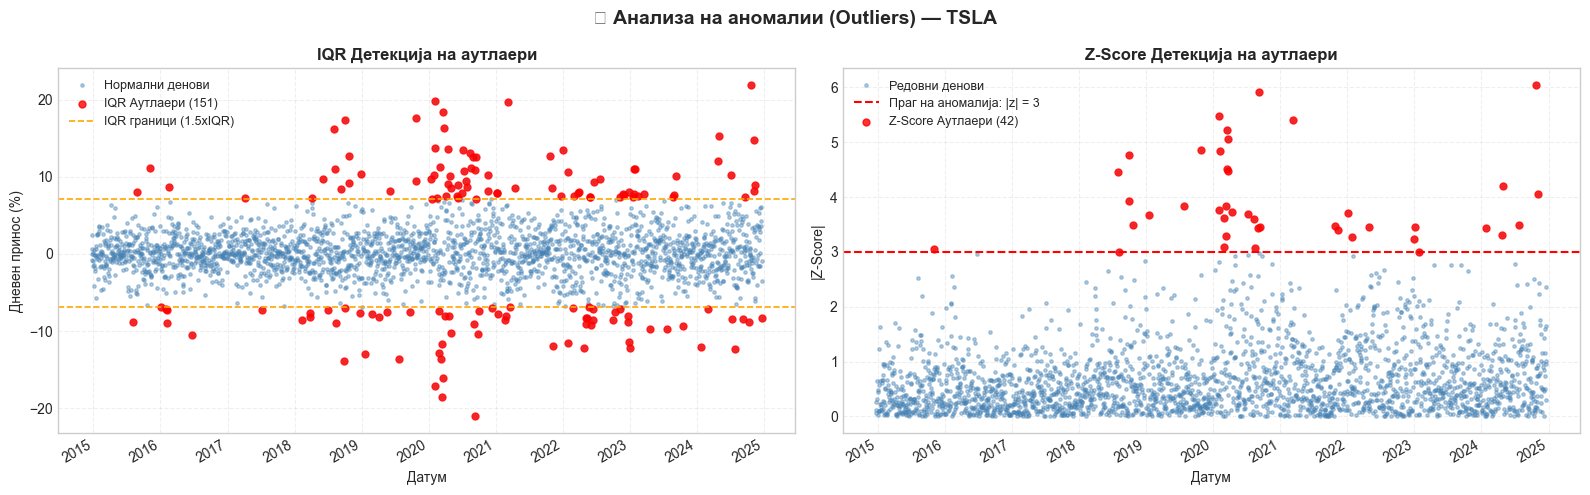

In [60]:
# Креирање на двата графикони еден до друг
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'🚨 Анализа на аномалии (Outliers) — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# График 1: IQR Детекција
ax1 = axes[0]
ax1.scatter(df['Date'], returns_pct, s=6, color='steelblue', alpha=0.4, label='Нормални денови')
ax1.scatter(outliers_iqr['Date'], outliers_iqr['Daily_Return_Raw']*100, s=25, color='red', alpha=0.8, label=f'IQR Аутлаери ({len(outliers_iqr)})')
ax1.axhline(lower_iqr, color='orange', linestyle='--', linewidth=1.2, label='IQR граници (1.5xIQR)')
ax1.axhline(upper_iqr, color='orange', linestyle='--', linewidth=1.2)
ax1.set_title('IQR Детекција на аутлаери', fontweight='bold')
ax1.set_xlabel('Датум')
ax1.set_ylabel('Дневен принос (%)')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# График 2: Z-Score Детекција
ax2 = axes[1]
ax2.scatter(df['Date'], z_scores, s=6, color='steelblue', alpha=0.4, label='Редовни денови')
ax2.axhline(3, color='red', linestyle='--', linewidth=1.5, label='Праг на аномалија: |z| = 3')
ax2.scatter(df.loc[z_scores > 3, 'Date'], z_scores[z_scores > 3], s=25, color='red', alpha=0.8, label=f'Z-Score Аутлаери ({len(outliers_zscore)})')
ax2.set_title('Z-Score Детекција на аутлаери', fontweight='bold')
ax2.set_xlabel('Датум')
ax2.set_ylabel('|Z-Score|')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

Топ 10 Најлуди денови во историјата на Тесла

In [61]:
print("\n🔴 Топ 10 денови со најекстремни пазарни движења:")
top_outliers = outliers_iqr.copy()
top_outliers['Daily_Return (%)'] = (top_outliers['Daily_Return_Raw'] * 100).round(2)
top_outliers['|Return (%)|'] = top_outliers['Daily_Return (%)'].abs()

# Приказ на средена табела во проценти
display(top_outliers.sort_values('|Return (%)|', ascending=False)
        [['Date', 'Close', 'Volume', 'Daily_Return (%)']]
        .head(10).reset_index(drop=True))

print("\n💡 Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува")
print("   хронолошкиот континуитет и интегритетот на временската серија.")


🔴 Топ 10 денови со најекстремни пазарни движења:


,Date,Close,Volume,Daily_Return (%)
0,2024-10-24,260.480011,204491900.0,21.92
1,2020-09-08,110.070000,346397100.0,-21.06
2,2020-02-03,52.000000,705975000.0,19.89
3,2021-03-09,224.526672,202569900.0,19.64
4,2020-03-16,29.671333,307342500.0,-18.58
5,2020-03-19,28.509333,452932500.0,18.39
6,2019-10-24,19.978666,445813500.0,17.67
7,2018-10-01,20.713333,326664000.0,17.35
8,2020-02-05,48.980000,726357000.0,-17.18
9,2020-03-24,33.666668,343428000.0,16.28



💡 Забелешка: Пронајдените аутлаери НЕ СЕ бришат од датасетот со цел да се зачува
   хронолошкиот континуитет и интегритетот на временската серија.


### 4.1 Обработка на Outliers — Capping (Winsorization)

Примена на Capping (Винзоризација)

In [62]:
# 1. Наоѓање на оригиналните децимални граници (IQR)
q1_raw = df['Daily_Return_Raw'].quantile(0.25)
q3_raw = df['Daily_Return_Raw'].quantile(0.75)
iqr_raw = q3_raw - q1_raw
lower_raw = q1_raw - 1.5 * iqr_raw
upper_raw = q3_raw + 1.5 * iqr_raw

# 2. Примена на Capping (Ограничување) — .clip() ги заковува вредностите на границите
df['Daily_Return_Cleaned'] = df['Daily_Return_Raw'].clip(lower=lower_raw, upper=upper_raw)

# 3. Подготовка на проценти само за визуелизација
cleaned_pct = df['Daily_Return_Cleaned'] * 100
lower_pct = lower_raw * 100
upper_pct = upper_raw * 100

print(f"✅ Capping (Winsorization) успешно применет врз приносите.")
print(f"   Математички граници за моделите: [{lower_raw:.4f}, {upper_raw:.4f}]")
print(f"   Визуелни граници во проценти:     [{lower_pct:.2f}%, {upper_pct:.2f}%]")

✅ Capping (Winsorization) успешно применет врз приносите.
   Математички граници за моделите: [-0.0684, 0.0716]
   Визуелни граници во проценти:     [-6.84%, 7.16%]


Верификација на исчистените податоци (Графикони)

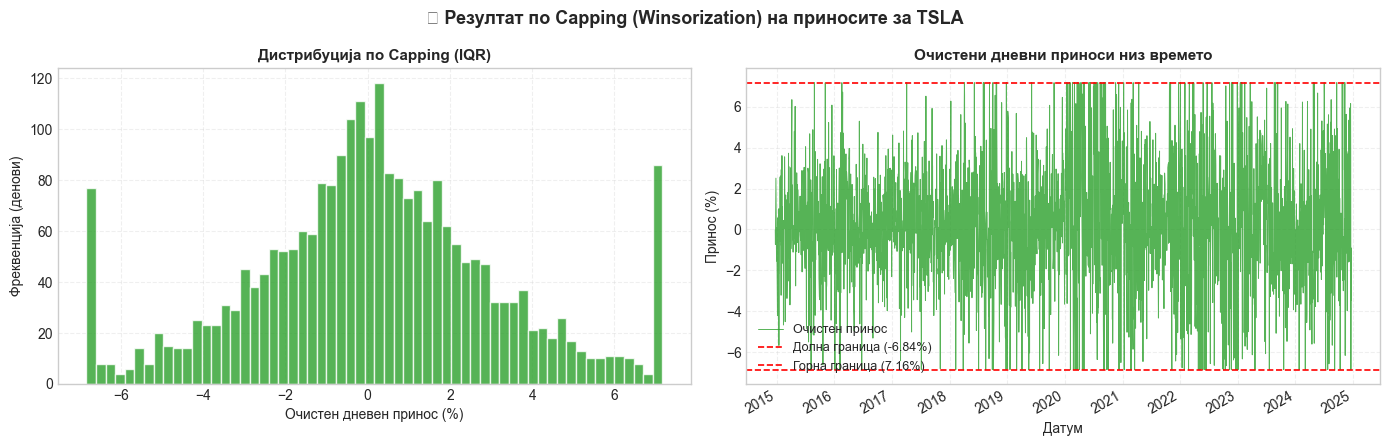

In [63]:


# Изречно ја дефинираме фигурата и двете под-графикончиња (axes) на почетокот на ќелијата
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f'🧹 Резултат по Capping (Winsorization) на приносите за {TICKER}', fontsize=13, fontweight='bold', y=0.98)

# 1) Хистограм по Capping
axes[0].hist(cleaned_pct, bins=60, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[0].set_title('Дистрибуција по Capping (IQR)', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Очистен дневен принос (%)')
axes[0].set_ylabel('Фреквенција (денови)')
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2) Временски приказ по Capping
axes[1].plot(df['Date'], cleaned_pct, color='#2ca02c', linewidth=0.7, alpha=0.8, label='Очистен принос')
axes[1].axhline(lower_pct, color='red', linestyle='--', linewidth=1.2, label=f'Долна граница ({lower_pct:.2f}%)')
axes[1].axhline(upper_pct, color='red', linestyle='--', linewidth=1.2, label=f'Горна граница ({upper_pct:.2f}%)')
axes[1].set_title('Очистени дневни приноси низ времето', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Принос (%)')
axes[1].legend(fontsize=9, loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Форматирање на датумите на X-оската
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## ⚙️ 5. Preprocessing — Window Size & Feature Engineering

**Window Size** е клучен хиперпараметар кај временски серии. Се однесува на 
бројот на минати денови кои ги гледаме за да го предвидиме наредниот ден.

**Вклучени карактеристики:**
- Подвижни просеци (SMA) и EMA за краткорочен и долгорочен тренд
- MACD spread (разлика на EMA за сигнали за влез/излез)
- RSI (индикатор за прекупеност / препродаденост)
- Bollinger Bands width (мерка на волатилност)
- Price momentum (моментум на движење)
- Волатилност (ролинг стандардна девијација)


In [64]:
# def build_features(data, window_short=7, window_long=21):
#     """
#     Изградба на богат feature set за предвидување на цени на акции.
    
#     Параметри:
#         window_short : краток прозорец (default=7 трговски денови ≈ 1 недела)
#         window_long  : долг прозорец  (default=21 трговски денови ≈ 1 месец)
#     """
#     data = data.copy()
    
#     # ── Trend: SMA и EMA ──
#     data['MA_7']  = data['Close'].rolling(window=window_short).mean()
#     data['MA_21'] = data['Close'].rolling(window=window_long).mean()
#     data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
#     data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
    
#     # ── Некорелирани (derived) карактеристики ──
#     data['MA_Trend_Diff']      = data['MA_7'] - data['MA_21']           # Bullish/Bearish crossover
#     data['EMA_Spread']         = data['EMA_12'] - data['EMA_26']        # MACD Spread
#     data['Price_to_MA7_Ratio'] = data['Close'] / (data['MA_7'] + 1e-9) # Нормализирана позиција

#     # ── Bollinger Bands ──
#     rolling_std = data['Close'].rolling(window=window_short).std()
#     data['BB_Upper'] = data['MA_7'] + 2 * rolling_std
#     data['BB_Lower'] = data['MA_7'] - 2 * rolling_std
#     data['BB_Width'] = (data['BB_Upper'] - data['BB_Lower']) / (data['MA_7'] + 1e-9)  # Нормализирана ширина

#     # ── Momentum ──
#     data['Momentum_5'] = data['Close'] - data['Close'].shift(5)   # 5-дневен моментум
#     data['Momentum_10'] = data['Close'] - data['Close'].shift(10) # 10-дневен моментум

#     # ── Волатилност ──
#     data['Volatility_7']  = data['Daily_Return_Cleaned'].rolling(window=window_short).std()
#     data['Volatility_21'] = data['Daily_Return_Cleaned'].rolling(window=window_long).std()
    
#     # ── КОРЕКЦИЈА: RSI со точно Вајлдерово експоненцијално измазнување (Wilder's EMA) ──
#     delta = data['Close'].diff()
#     gain = delta.clip(lower=0)
#     loss = -delta.clip(upper=0)
    
#     # Алфа за 14-дневен RSI според Вајлдер е 1/14
#     avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
#     avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
    
#     rs = avg_gain / (avg_loss + 1e-9)
#     data['RSI'] = 100 - (100 / (1 + rs))
    
#     # ── Лаг карактеристики ──
#     data['Close_Lag1'] = data['Close'].shift(1)
#     data['Close_Lag5'] = data['Close'].shift(5)
    
#     # ── Target: цената следниот ден ──
#     data['Target_Price'] = data['Close'].shift(-1)
    
#     # Бришење на почетните редови кои станаа NaN поради прозорците (rolling/lags/shifts)
#     data.dropna(inplace=True)
#     data.reset_index(drop=True, inplace=True)
#     return data

# # Примена на корегираната функција
# df_ml = build_features(df, window_short=7, window_long=21)

# print(f"✅ Feature Engineering завршен (Математички усогласен).")
# print(f"   Број на вкупни колони во DataFrame: {df_ml.shape[1]}")
# print(f"   Број на достапни денови за ML:      {df_ml.shape[0]}")
# print(f"\nКреирани карактеристики:")
# print(list(df_ml.columns))

In [65]:
# ── CELL 1: Подготовка и Trend Индикатори (SMA & EMA) ──

# Креираме копија од исчистениот df за да работиме на ML карактеристиките
df_ml = df.copy()

window_short = 7
window_long = 21

# Креирање на основните подвижни просеци
df_ml['MA_7']  = df_ml['Close'].rolling(window=window_short).mean()
df_ml['MA_21'] = df_ml['Close'].rolling(window=window_long).mean()
df_ml['EMA_12'] = df_ml['Close'].ewm(span=12, adjust=False).mean()
df_ml['EMA_26'] = df_ml['Close'].ewm(span=26, adjust=False).mean()

print("✅ Чекор 1: Креирани се SMA и EMA карактеристиките.")

✅ Чекор 1: Креирани се SMA и EMA карактеристиките.


In [66]:
# ── CELL 2: Изведени карактеристики и Bollinger Bands ──

# Некорелирани карактеристики (разлики и соодноси)
df_ml['MA_Trend_Diff']      = df_ml['MA_7'] - df_ml['MA_21']           # Bullish/Bearish crossover
df_ml['EMA_Spread']         = df_ml['EMA_12'] - df_ml['EMA_26']        # MACD Spread
df_ml['Price_to_MA7_Ratio'] = df_ml['Close'] / (df_ml['MA_7'] + 1e-9) # Нормализирана позиција

# Bollinger Bands пресметки
rolling_std = df_ml['Close'].rolling(window=window_short).std()
df_ml['BB_Upper'] = df_ml['MA_7'] + 2 * rolling_std
df_ml['BB_Lower'] = df_ml['MA_7'] - 2 * rolling_std
df_ml['BB_Width'] = (df_ml['BB_Upper'] - df_ml['BB_Lower']) / (df_ml['MA_7'] + 1e-9)  # Нормализирана ширина

print("✅ Чекор 2: Креирани се Bollinger Bands и тренд диференцијалите.")

✅ Чекор 2: Креирани се Bollinger Bands и тренд диференцијалите.


In [67]:
# ── CELL 3: Momentum & Волатилност ──

# Пазарен Моментум (Брзина на промена на цената)
df_ml['Momentum_5'] = df_ml['Close'] - df_ml['Close'].shift(5)   # 5-дневен моментум
df_ml['Momentum_10'] = df_ml['Close'] - df_ml['Close'].shift(10) # 10-дневен моментум

# Ролинг волатилност (од претходно исчистените приноси)
df_ml['Volatility_7']  = df_ml['Daily_Return_Cleaned'].rolling(window=window_short).std()
df_ml['Volatility_21'] = df_ml['Daily_Return_Cleaned'].rolling(window=window_long).std()

print("✅ Чекор 3: Креирани се Momentum и Волатилност индикаторите.")

✅ Чекор 3: Креирани се Momentum и Волатилност индикаторите.


In [68]:
# ── CELL 4: RSI Индикатор (Wilder's Smoothing) ──

delta = df_ml['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

# Алфа за 14-дневен RSI според Вајлдер е 1/14
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()

rs = avg_gain / (avg_loss + 1e-9)
df_ml['RSI'] = 100 - (100 / (1 + rs))

print("✅ Чекор 4: Пресметан е точниот RSI индикатор.")

✅ Чекор 4: Пресметан е точниот RSI индикатор.


In [69]:
# ── CELL 5: Лагови и Креирање на Target (Ознака за предвидување) ──

# Временски лагови (Поглед наназад)
df_ml['Close_Lag1'] = df_ml['Close'].shift(1)
df_ml['Close_Lag5'] = df_ml['Close'].shift(5)

# TARGET: Цената следниот работен ден (Што треба да предвидиме)
df_ml['Target_Price'] = df_ml['Close'].shift(-1)

print("✅ Чекор 5: Лаговите и Target вредноста се успешно поставени.")

✅ Чекор 5: Лаговите и Target вредноста се успешно поставени.


In [70]:
# ── CELL 6: Чистење на NaN и Финална инспекција ──

# Бидејќи имаме rolling(21) и shift(10), првите 21 редови ќе бидат NaN. Ги бришеме за чист тренинг.
df_ml.dropna(inplace=True)
df_ml.reset_index(drop=True, inplace=True)

print(f"🎉 FEATURE ENGINEERING Е ЦЕЛОСНО ЗАВРШЕН!\n")
print(f"📊 Димензии на финалната матрица за Machine Learning: {df_ml.shape[0]:,} денови x {df_ml.shape[1]} колони")
print(f"\n📋 Список на сите достапни карактеристики:")
print("-" * 65)
for index, col in enumerate(df_ml.columns, 1):
    print(f"{index:02d}. {col}")

🎉 FEATURE ENGINEERING Е ЦЕЛОСНО ЗАВРШЕН!

📊 Димензии на финалната матрица за Machine Learning: 2,496 денови x 31 колони

📋 Список на сите достапни карактеристики:
-----------------------------------------------------------------
01. Date
02. Symbol
03. Adj Close
04. Close
05. High
06. Low
07. Open
08. Volume
09. S&P500
10. Longname
11. Sector
12. Daily_Return_Raw
13. Daily_Return_Cleaned
14. MA_7
15. MA_21
16. EMA_12
17. EMA_26
18. MA_Trend_Diff
19. EMA_Spread
20. Price_to_MA7_Ratio
21. BB_Upper
22. BB_Lower
23. BB_Width
24. Momentum_5
25. Momentum_10
26. Volatility_7
27. Volatility_21
28. RSI
29. Close_Lag1
30. Close_Lag5
31. Target_Price


### 5.1 Анализа на Window Size — Влијание врз предвидувањето

In [71]:
# # ── Демонстрација: Различни window sizes и нивниот ефект на MA ──

# # ПРЕПРАВКА: Прво ги пресметуваме индикаторите на ЦЕЛИОТ df за да нема празнини кај големите прозорци (MA-200)
# df_ma_demo = df.copy()

# # Пресметка за првиот графикон
# ma_windows = [7, 21, 50, 200]
# for w in ma_windows:
#     df_ma_demo[f'MA_{w}'] = df_ma_demo['Close'].rolling(w).mean()

# # Пресметка за вториот графикон
# df_ma_demo['SMA_7'] = df_ma_demo['Close'].rolling(7).mean()
# df_ma_demo['EMA_7'] = df_ma_demo['Close'].ewm(span=7, adjust=False).mean()

# # СЕГА ги земаме само последните 500 записи за прегледна визуелизација
# sample = df_ma_demo.tail(500)

# # Креирање на графиконите
# fig, axes = plt.subplots(2, 1, figsize=(16, 11))
# fig.suptitle(f'📉 Влијание на Window Size врз Moving Averages — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# # 1) Горен графикон: Различни MA прозорци (Линиите сега ќе бидат комплетни)
# axes[0].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1.2, alpha=0.6, label='Close цена')
# colors_ma = {7: '#d62728', 21: '#2ca02c', 50: '#ff7f0e', 200: '#9467bd'}

# for w in ma_windows:
#     # Точно (буквата f треба да биде ОДНАДВОР за да се активира f-string форматирањето):
#     axes[0].plot(sample['Date'], sample[f'MA_{w}'], linewidth=1.5, label=f'MA-{w} (Прозорец {w}д)', color=colors_ma[w])

# axes[0].set_title('Споредба на Moving Averages со различни прозорци (Долгорочни vs Краткорочни трендови)', fontweight='bold')
# axes[0].set_ylabel('Цена ($)')
# axes[0].legend(fontsize=9, loc='upper left')
# axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# axes[0].tick_params(axis='x', rotation=30)  # Елегантно ротирање на горната оска

# # 2) Долен графикон: EMA vs SMA за краток прозорец (7)
# axes[1].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1, alpha=0.4, label='Close цена')
# axes[1].plot(sample['Date'], sample['SMA_7'], linewidth=1.6, color='#d62728', label='SMA-7 (Порамномерен тренд)')
# axes[1].plot(sample['Date'], sample['EMA_7'], linewidth=1.6, color='#2ca02c', linestyle='--', label='EMA-7 (Пореактивен на нови цени)')

# axes[1].set_title('SMA vs EMA (прозорец = 7 дена): Споредба на реактивност', fontweight='bold')
# axes[1].set_ylabel('Цена ($)')
# axes[1].set_xlabel('Датум')
# axes[1].legend(fontsize=9, loc='upper left')
# axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# axes[1].tick_params(axis='x', rotation=30)  # Елегантно ротирање на долната оска

# plt.tight_layout()
# plt.show()

# print("💡 СТРУЧЕН ЗАКЛУЧОК ЗА ПРЕЗЕНТАЦИЈА:")
# print("   • Помал прозорец (7)   → Исклучително осетлив на секоја дневна промена, но содржи многу пазарен шум.")  
# print("   • Поголем прозорец (200) → Го маскира шумот и го открива долгорочниот структурен тренд, но генерира задоцнети сигнали.")
# print("   • EMA vs SMA           → Експоненцијалниот просек (EMA) реагира моментално на најновите ценовни шокови,")
# print("                            додека обичниот просек (SMA) рамномерно ги третира сите денови во минатото.")

In [72]:
# ── CELL 1: Подготовка на податоци за Window Size демонстрација ──

# Прво ги пресметуваме индикаторите на ЦЕЛИОТ df за да нема празнини кај големите прозорци (MA-200)
df_ma_demo = df.copy()

# Пресметка за првиот графикон (Различни прозорци)
ma_windows = [7, 21, 50, 200]
for w in ma_windows:
    df_ma_demo[f'MA_{w}'] = df_ma_demo['Close'].rolling(w).mean()

# Пресметка за вториот графикон (SMA vs EMA)
df_ma_demo['SMA_7'] = df_ma_demo['Close'].rolling(7).mean()
df_ma_demo['EMA_7'] = df_ma_demo['Close'].ewm(span=7, adjust=False).mean()

# СЕГА ги земаме само последните 500 записи за прегледна визуелизација
sample = df_ma_demo.tail(500)

print("✅ Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!")

✅ Чекор 1: Сите Moving Averages (7, 21, 50, 200) и EMA се успешно пресметани!


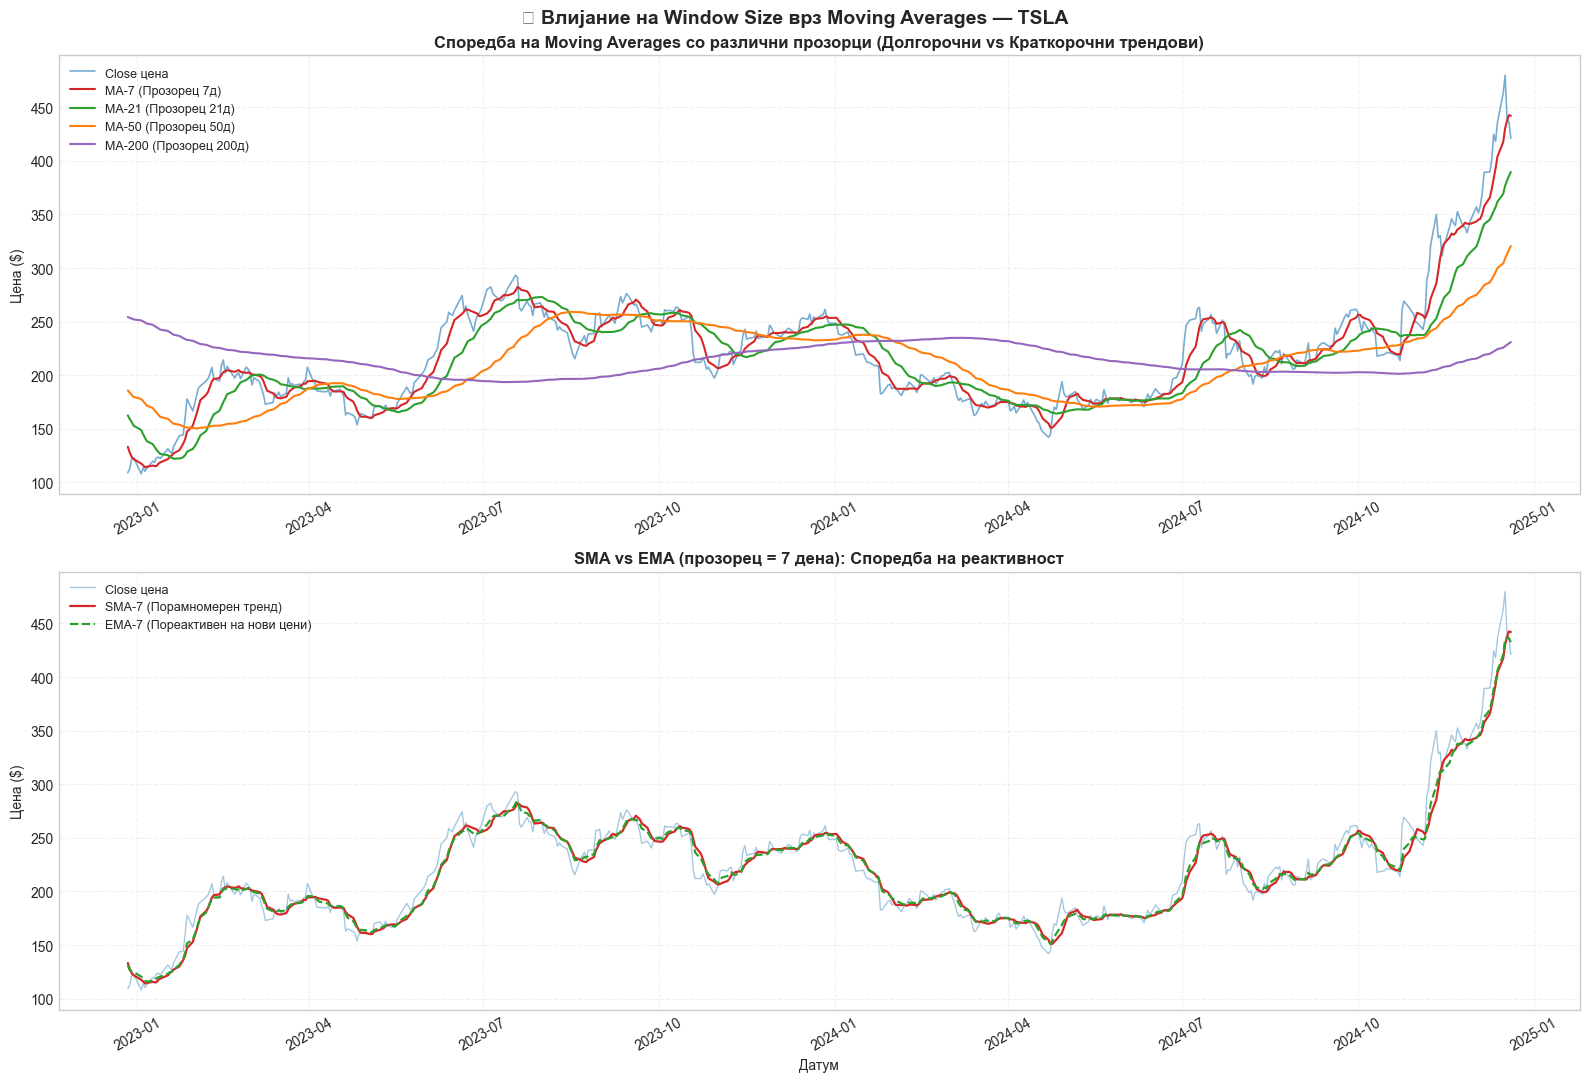

In [73]:
# ── CELL 2: Визуелизација на Moving Averages и Реактивност ──

fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle(f'📉 Влијание на Window Size врз Moving Averages — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Горен графикон: Различни MA прозорци (Линиите сега се комплетни)
axes[0].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1.2, alpha=0.6, label='Close цена')
colors_ma = {7: '#d62728', 21: '#2ca02c', 50: '#ff7f0e', 200: '#9467bd'}

for w in ma_windows:
    axes[0].plot(sample['Date'], sample[f'MA_{w}'], linewidth=1.5, label=f'MA-{w} (Прозорец {w}д)', color=colors_ma[w])

axes[0].set_title('Споредба на Moving Averages со различни прозорци (Долгорочни vs Краткорочни трендови)', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)  # Елегантно ротирање на горната оска
axes[0].grid(True, linestyle='--', alpha=0.3)

# 2) Долен графикон: EMA vs SMA за краток прозорец (7)
axes[1].plot(sample['Date'], sample['Close'], color='#1f77b4', linewidth=1, alpha=0.4, label='Close цена')
axes[1].plot(sample['Date'], sample['SMA_7'], linewidth=1.6, color='#d62728', label='SMA-7 (Порамномерен тренд)')
axes[1].plot(sample['Date'], sample['EMA_7'], linewidth=1.6, color='#2ca02c', linestyle='--', label='EMA-7 (Пореактивен на нови цени)')

axes[1].set_title('SMA vs EMA (прозорец = 7 дена): Споредба на реактивност', fontweight='bold')
axes[1].set_xlabel('Датум')
axes[1].set_ylabel('Цена ($)')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)  # Елегантно ротирање на долната оска
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [74]:
# ── CELL 3: Стручен заклучок од анализата ──

print("=" * 70)
print("💡 СТРУЧЕН ЗАКЛУЧОК ЗА ПРЕЗЕНТАЦИЈА:")
print("=" * 70)
print("  • Помал прозорец (7 дена)  → Исклучително осетлив на секоја дневна промена,\n    но содржи многу пазарен шум.")  
print("  • Поголем прозорец (200 дена) → Го маскира шумот и го открива долгорочниот\n    структурен тренд, но генерира задоцнети сигнали (lagging indicators).")
print("  • EMA vs SMA (7 дена)     → Експоненцијалниот просек (EMA) реагира моментално\n    на најновите ценовни шокови, додека обичниот просек (SMA) рамномерно\n    ги третира сите денови во минатото.")
print("=" * 70)

💡 СТРУЧЕН ЗАКЛУЧОК ЗА ПРЕЗЕНТАЦИЈА:
  • Помал прозорец (7 дена)  → Исклучително осетлив на секоја дневна промена,
    но содржи многу пазарен шум.
  • Поголем прозорец (200 дена) → Го маскира шумот и го открива долгорочниот
    структурен тренд, но генерира задоцнети сигнали (lagging indicators).
  • EMA vs SMA (7 дена)     → Експоненцијалниот просек (EMA) реагира моментално
    на најновите ценовни шокови, додека обичниот просек (SMA) рамномерно
    ги третира сите денови во минатото.


## 📊 6. Корелациска Анализа

In [75]:
# # КОРЕКЦИЈА: Го тргаме суровиот 'Close' од карактеристиките за тренирање за да спречиме тривијално учење.
# # Ги задржуваме лаговите и нормализираните карактеристики кои се математички правилни.
# feature_cols = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
#                 'BB_Width', 'Momentum_5', 'Volatility_7', 'RSI',
#                 'Close_Lag1', 'Close_Lag5', 'Target_Price']

# fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
# fig.suptitle(f'📊 Корелациска и Мултиколинеарна Анализа на карактеристики — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# # 1) Триаголна Хитмапа
# corr = df_ml[feature_cols].corr()
# mask = np.triu(np.ones_like(corr, dtype=bool))
# sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
#             linewidths=0.3, ax=axes[0], mask=mask, annot_kws={"size": 9})
# axes[0].set_title('Корелациска матрица (Долно-триаголен приказ)', fontsize=11, fontweight='bold')
# axes[0].tick_params(axis='x', rotation=35, labelsize=9)
# axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# # 2) Корелација специфично со Target променливата
# target_corr = corr['Target_Price'].drop('Target_Price').sort_values(ascending=True)
# colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
# axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)
# axes[1].axvline(0, color='black', linewidth=0.8, linestyle='-')
# axes[1].set_title('Влијание на карактеристиките врз Target_Price (Pearson)', fontsize=11, fontweight='bold')
# axes[1].set_xlabel('Корелациски Коефициент (r)')

# # Додавање на вредностите како текст на самите барови
# for i, v in enumerate(target_corr.values):
#     offset = 0.015 if v >= 0 else -0.015
#     align = 'left' if v >= 0 else 'right'
#     axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontsize=9, fontweight='bold')

# plt.tight_layout()
# plt.show()

# # ── Анализа на Мултиколинеарност ──
# print("=" * 65)
# print("⚠️  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):")
# print("=" * 65)
# high_corr = []
# for i in range(len(corr.columns)):
#     for j in range(i+1, len(corr.columns)):
#         # Ги проверуваме сите парови освен Target променливата
#         if corr.columns[i] != 'Target_Price' and corr.columns[j] != 'Target_Price':
#             if abs(corr.iloc[i,j]) > 0.90:
#                 high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

# if high_corr:
#     for a, b, r in high_corr:
#         print(f" 🔴 Висок ризик: {a} ↔ {b} | r = {r:.4f}")
#     print("\n💡 Објаснување за одбрана:")
#     print("   Силно корелираните карактеристики (како временските лагови) содржат")
#     print("   дуплирани информации. Моделите базирани на дрвја (XGBoost, Random Forest)")
#     print("   се робусни на ова, но кај линеарните модели ова може да ги дестабилизира коефициентите.")
# else:
#     print(" ✅ Одлично! Нема пронајдено критична мултиколинеарност меѓу влезните карактеристики.")
# print("=" * 65)

In [76]:
# ── CELL 1: Пресметка на Корелациска Матрица ──

# Дефинирање на карактеристиките кои ќе ги анализираме
feature_cols = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
                'BB_Width', 'Momentum_5', 'Volatility_7', 'RSI',
                'Close_Lag1', 'Close_Lag5', 'Target_Price']

# Пресметка на Pearson-овиот коефициент на корелација
corr = df_ml[feature_cols].corr()

print("✅ Чекор 1: Корелациската матрица за избраните карактеристики е успешно пресметана.")

✅ Чекор 1: Корелациската матрица за избраните карактеристики е успешно пресметана.


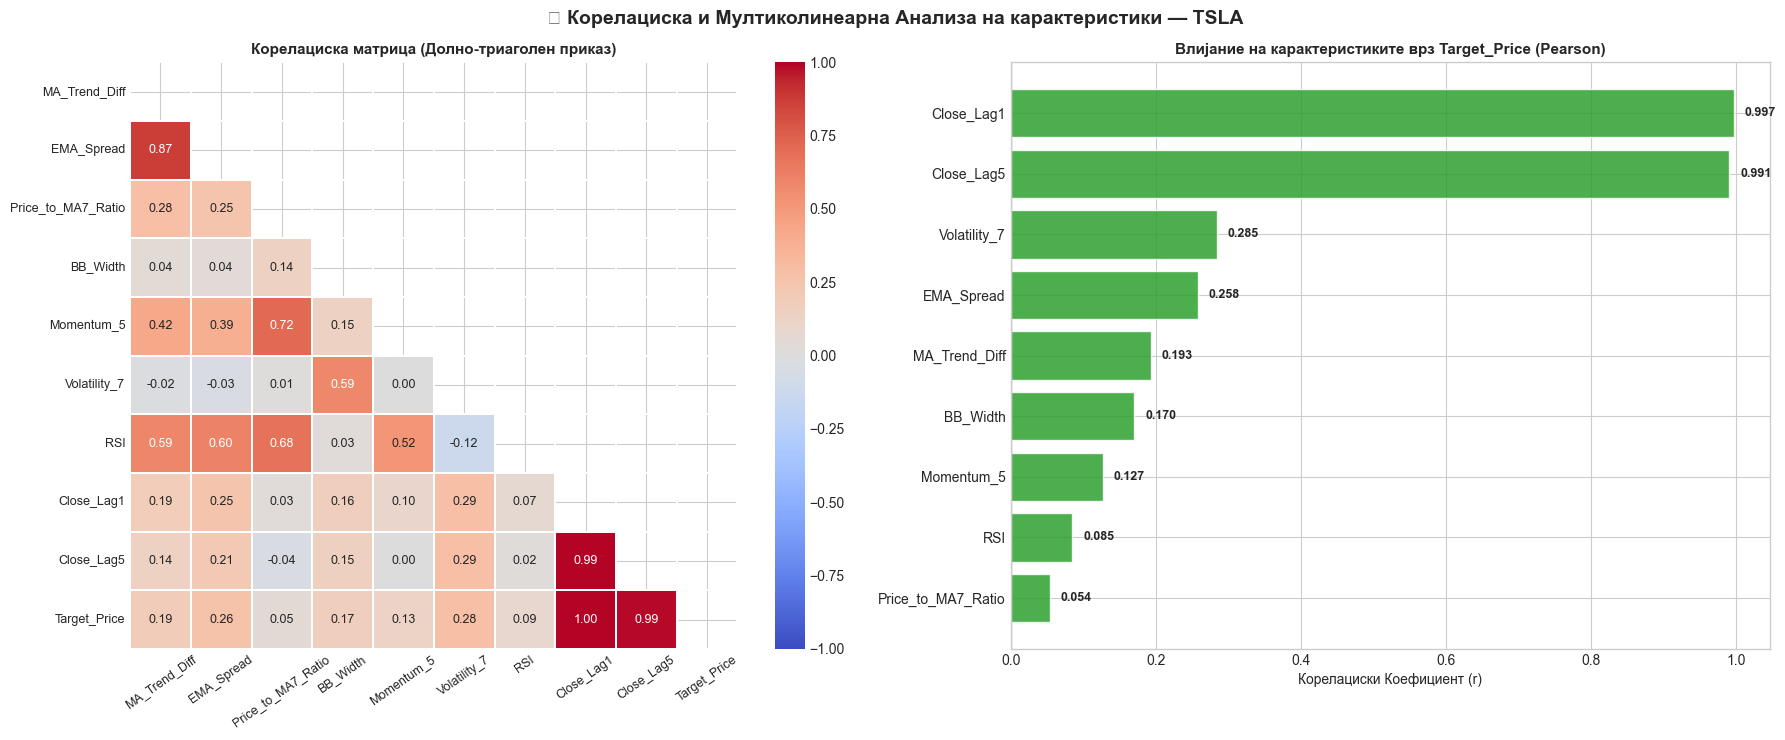

In [77]:
# ── CELL 2: Визуелизација на Корелација и Влијание врз Target ──

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
fig.suptitle(f'📊 Корелациска и Мултиколинеарна Анализа на карактеристики — {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Триаголна Хитмапа (Долно-триаголен приказ)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.3, ax=axes[0], mask=mask, annot_kws={"size": 9})

axes[0].set_title('Корелациска матрица (Долно-триаголен приказ)', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=35, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# 2) Корелација специфично со Target променливата
target_corr = corr['Target_Price'].drop('Target_Price').sort_values(ascending=True)
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='-')
axes[1].set_title('Влијание на карактеристиките врз Target_Price (Pearson)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Корелациски Коефициент (r)')

# Додавање на вредностите како текст на самите барови
for i, v in enumerate(target_corr.values):
    offset = 0.015 if v >= 0 else -0.015
    align = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=align, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [78]:
# ── CELL 3: Автоматска Детекција на Мултиколинеарност (|r| > 0.90) ──

print("=" * 65)
print("⚠️  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):")
print("=" * 65)

high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        # Ги проверуваме сите парови освен соодносот со самата Target_Price
        if corr.columns[i] != 'Target_Price' and corr.columns[j] != 'Target_Price':
            if abs(corr.iloc[i,j]) > 0.90:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

if high_corr:
    for a, b, r in high_corr:
        print(f" 🔴 Висок ризик: {a} ↔ {b} | r = {r:.4f}")
    print("\n💡 Објаснување за одбрана на трудот:")
    print("   Силно корелираните карактеристики (како временските лагови Close_Lag1 и Close_Lag5)")
    print("   содржат дуплирани пазарни информации. Моделите базирани на дрвја (XGBoost, Random Forest)")
    print("   се робусни на ова, но кај чисто линеарните модели ова може да ги дестабилизира коефициентите.")
else:
    print(" ✅ Одлично! Нема пронајдено критична мултиколинеарност меѓу влезните карактеристики.")
print("=" * 65)

⚠️  ДЕТЕКЦИЈА НА ВИСОКА МУЛТИКОЛИНЕАРНОСТ (|r| > 0.90):
 🔴 Висок ризик: Close_Lag1 ↔ Close_Lag5 | r = 0.9940

💡 Објаснување за одбрана на трудот:
   Силно корелираните карактеристики (како временските лагови Close_Lag1 и Close_Lag5)
   содржат дуплирани пазарни информации. Моделите базирани на дрвја (XGBoost, Random Forest)
   се робусни на ова, но кај чисто линеарните модели ова може да ги дестабилизира коефициентите.


In [79]:
# Чистење на мултиколинеарната карактеристика
df_ml.drop(columns=['Close_Lag5'], inplace=True, errors='ignore')

print("🧹 Успешно исфрлена колоната 'Close_Lag5' за да се елиминира мултиколинеарноста.")
print(f"Нови димензии на датасетот: {df_ml.shape[0]} денови x {df_ml.shape[1]} колони")

🧹 Успешно исфрлена колоната 'Close_Lag5' за да се елиминира мултиколинеарноста.
Нови димензии на датасетот: 2496 денови x 30 колони


## ✂️ 7. Train/Test Split — Хронолошки

Кај временски серии е **забрането** да се користи рандом сплит.  
Секогаш тренираме на минатото и тестираме на иднината (80/20).


In [80]:
# # Дефинирање на feature columns (без 'Close' за да избегнеме leakage)
# FEATURE_COLS = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
#                 'BB_Width', 'Momentum_5', 'Momentum_10',
#                 'Volatility_7', 'Volatility_21', 'RSI',
#                 'Daily_Return_Cleaned', 'Close_Lag1', 'Close_Lag5']

# X = df_ml[FEATURE_COLS]
# y = df_ml['Target_Price']

# # Хронолошки сплит на 80% за тренирање и 20% за тестирање
# split_idx = int(len(df_ml) * 0.80)

# X_train_raw = X.iloc[:split_idx]
# X_test_raw  = X.iloc[split_idx:]
# y_train     = y.iloc[:split_idx]
# y_test      = y.iloc[split_idx:]

# print(f"📐 Хронолошки сплит: 80% тренирање / 20% тестирање")
# print(f"   Тренинг период:  {df_ml['Date'].iloc[0].date()} → {df_ml['Date'].iloc[split_idx-1].date()} ({len(y_train)} денови)")
# print(f"   Тест период:     {df_ml['Date'].iloc[split_idx].date()} → {df_ml['Date'].iloc[-1].date()} ({len(y_test)} денови)")

# # Визуелен приказ на поделбата
# fig, ax = plt.subplots(figsize=(16, 4.5))
# ax.plot(df_ml['Date'].iloc[:split_idx], y_train, label=f'Тренинг сет ({len(y_train)} денови)', color='royalblue', linewidth=1.2)
# ax.plot(df_ml['Date'].iloc[split_idx:], y_test,  label=f'Тест сет ({len(y_test)} денови)',     color='darkorange', linewidth=1.2)
# ax.axvline(df_ml['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=1.5, label='Граница на поделба (Train/Test Split)')
# ax.set_title(f'📊 Хронолошка поделба на податоците за {TICKER} (Спречување на Look-Ahead Bias)', fontsize=13, fontweight='bold', pad=10)
# ax.set_ylabel('Цена на акција ($)')
# ax.set_xlabel('Датум')
# ax.legend(fontsize=9, loc='upper left')
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
# plt.tight_layout()
# plt.show()

# # ── ДОДАТОК: Зачувување на оригиналните денешни цени за тест сетот (потребно за Naive Baseline) ──
# # Бидејќи во X_test_raw колоната 'Close_Lag1' претставува актуелната цена за тој ден во однос на Target_Price
# y_test_current_prices = X_test_raw['Close_Lag1'].copy()

# # Скалирање на карактеристиките
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_raw)
# X_test_scaled  = scaler.transform(X_test_raw)

# print("\n✅ StandardScaler успешно применет.")
# print("   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.")
# print("   • Матрицата за тренирање е безбедна од Data Leakage.")

In [81]:
# ── CELL 1: Хронолошки сплит (Спречување на Look-Ahead Bias) ──

# Дефинирање на feature columns (без 'Close' за да избегнеме leakage)
FEATURE_COLS = ['MA_Trend_Diff', 'EMA_Spread', 'Price_to_MA7_Ratio',
                'BB_Width', 'Momentum_5', 'Momentum_10',
                'Volatility_7', 'Volatility_21', 'RSI',
                'Daily_Return_Cleaned', 'Close_Lag1',]

X = df_ml[FEATURE_COLS]
y = df_ml['Target_Price']

# Хронолошки сплит на 80% за тренирање и 20% за тестирање
split_idx = int(len(df_ml) * 0.80)

X_train_raw = X.iloc[:split_idx]
X_test_raw  = X.iloc[split_idx:]
y_train     = y.iloc[:split_idx]
y_test      = y.iloc[split_idx:]

print(f"📐 Хронолошки сплит: 80% тренирање / 20% тестирање")
print(f"   Тренинг период:  {df_ml['Date'].iloc[0].date()} → {df_ml['Date'].iloc[split_idx-1].date()} ({len(y_train)} денови)")
print(f"   Тест период:     {df_ml['Date'].iloc[split_idx].date()} → {df_ml['Date'].iloc[-1].date()} ({len(y_test)} денови)")

📐 Хронолошки сплит: 80% тренирање / 20% тестирање
   Тренинг период:  2015-01-22 → 2022-12-22 (1996 денови)
   Тест период:     2022-12-23 → 2024-12-19 (500 денови)


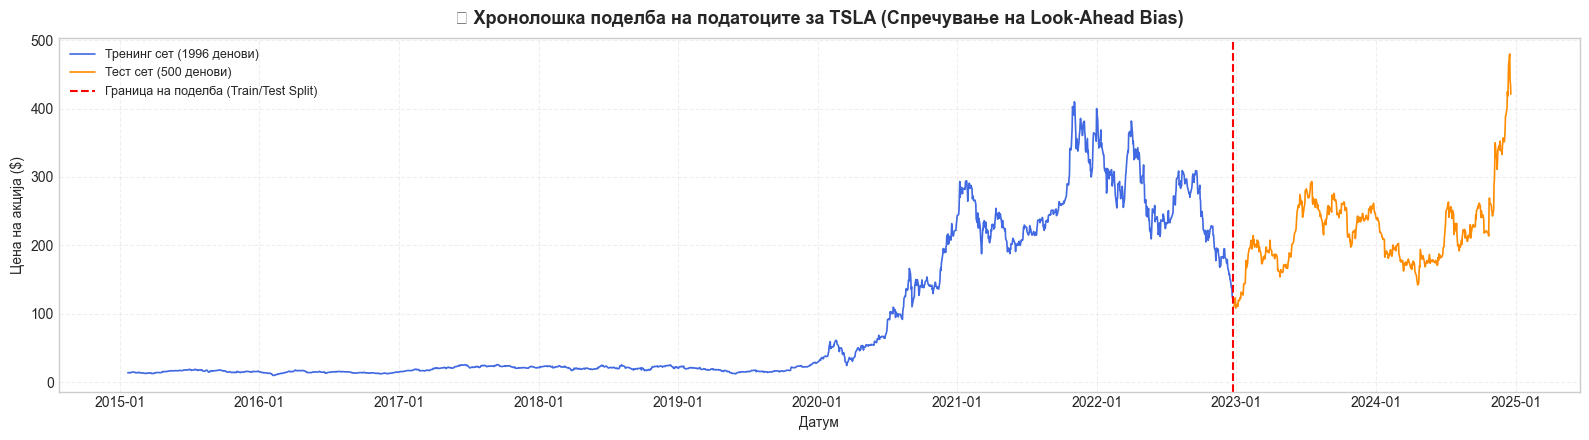

In [82]:
# ── CELL 2: Визуелен приказ на поделбата ──

fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(df_ml['Date'].iloc[:split_idx], y_train, label=f'Тренинг сет ({len(y_train)} денови)', color='royalblue', linewidth=1.2)
ax.plot(df_ml['Date'].iloc[split_idx:], y_test,  label=f'Тест сет ({len(y_test)} денови)',     color='darkorange', linewidth=1.2)
ax.axvline(df_ml['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=1.5, label='Граница на поделба (Train/Test Split)')

ax.set_title(f'📊 Хронолошка поделба на податоците за {TICKER} (Спречување на Look-Ahead Bias)', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Цена на акција ($)')
ax.set_xlabel('Датум')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:
# ── CELL 3: Зачувување на базни цени и Скалирање (StandardScaler) ──

# Зачувување на оригиналните денешни цени за тест сетот (потребно за Naive Baseline)
# Бидејќи во X_test_raw колоната 'Close_Lag1' претставува актуелната цена за тој ден во однос на Target_Price
y_test_current_prices = X_test_raw['Close_Lag1'].copy()

# Скалирање на карактеристиките
scaler = StandardScaler()

# Важно: Вршиме fit само на тренинг податоците
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw) 

print("✅ StandardScaler успешно применет.")
print("   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.")
print("   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).")

✅ StandardScaler успешно применет.
   • Моделот ќе учи од карактеристики каде просекот е 0 и варијансата е 1.
   • Матрицата за тренирање е безбедна од Data Leakage (фитот е направен исклучиво на минатото).


## 🤖 8. Тренирање на ML Модели

Тренираме 4 класични ML модели и ги споредуваме со Наивна Базна линија.

| Модел | Предности | Слабости |
|-------|-----------|---------|
| Random Forest | Робустен, не оверфитува лесно | Sporiji за inference |
| KNN | Едноставен, без претпоставки | Чувствителен на скала |
| SVM | Добар за нелинеарни врски | Бавен на голем датасет |
| XGBoost | Најдобар перформанс генерално | Повеќе хиперпараметри |


Дефинирање на ML моделите со регуларизација

In [84]:
import time
print("🤖 Подготовка на пазарните ML модели со заштита од overfitting...")

# Дефинирање на алгоритмите со хиперпараметри против overfitting
all_models = {
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42),
    "KNN":           KNeighborsRegressor(n_neighbors=7, weights='distance'),
    "SVM":           SVR(kernel='rbf', C=10.0, epsilon=0.05, gamma='scale'),
    "XGBoost":       XGBRegressor(n_estimators=200, learning_rate=0.03, max_depth=5,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0),
}

train_times = {}
print("✅ Моделите се успешно конфигурирани во меморијата!")

🤖 Подготовка на пазарните ML модели со заштита од overfitting...
✅ Моделите се успешно конфигурирани во меморијата!


Поставување на Naive Baseline (Базна линија)

In [85]:
# Пресметка за Наивната базна линија (Време: 0s)
# Напомена: Како предвидување за утре се зема актуелната денешна цена (Close_Lag1)
train_times["Naive Baseline"] = 0.00
print(f"   ✅ [{train_times['Naive Baseline']:5.2f}s] Naive Baseline — поставена како базна линија")

   ✅ [ 0.00s] Naive Baseline — поставена како базна линија


Тренирање (Обука) на сите ML модели

In [86]:
print("🚀 Тренирање на пазарните ML модели врз скалираните податоци...")

# Тренирање на останатите ML модели
for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train) # Моделот учи од скалираните X и оригиналните y
    train_times[name] = round(time.time() - t0, 2)
    print(f"   ✅ [{train_times[name]:5.2f}s] {name} — тренирање успешно завршено")

print("\n🏆 Сите пазарни модели се успешно истренирани и подготвени за евалуација.")

🚀 Тренирање на пазарните ML модели врз скалираните податоци...
   ✅ [ 3.37s] Random Forest — тренирање успешно завршено
   ✅ [ 0.06s] KNN — тренирање успешно завршено
   ✅ [ 0.33s] SVM — тренирање успешно завршено
   ✅ [ 0.55s] XGBoost — тренирање успешно завршено

🏆 Сите пазарни модели се успешно истренирани и подготвени за евалуација.


### 8.1 Евалуација и споредба на ML модели

Дефинирање на Функцијата за Евалуација

In [87]:


def evaluate_model(name, model, X_t, y_t, y_tr, X_tr):
    # Моделот прави предвидувања за тест и тренинг сетот
    preds = model.predict(X_t)
    preds_train = model.predict(X_tr)
    
    # Пресметка на метриките
    mae   = mean_absolute_error(y_t, preds)
    rmse  = np.sqrt(mean_squared_error(y_t, preds))
    r2    = r2_score(y_t, preds)
    mape  = np.mean(np.abs((y_t - preds) / (y_t + 1e-9))) * 100
    r2_tr = r2_score(y_tr, preds_train)
    
    return {
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2),
        "R² Test (%)": round(r2 * 100, 2),
        "R² Train (%)": round(r2_tr * 100, 2),
        "MAPE (%)": round(mape, 2),
        "Overfit Gap": round((r2_tr - r2) * 100, 2)
    }

print("✅ Функцијата `evaluate_model` е подготвена за работа.")

✅ Функцијата `evaluate_model` е подготвена за работа.


Евалуација и Печатење на Споредбената Табела

In [88]:
# 1) Точна пресметка на Naïve Baseline
naive_mae  = mean_absolute_error(y_test, y_test_current_prices)
naive_rmse = np.sqrt(mean_squared_error(y_test, y_test_current_prices))
naive_r2   = r2_score(y_test, y_test_current_prices)
naive_mape = np.mean(np.abs((y_test - y_test_current_prices) / (y_test + 1e-9))) * 100

comparison_results = {}

# 2) Евалуација на сите класични ML модели
for name, model in all_models.items():
    comparison_results[name] = evaluate_model(name, model, X_test_scaled, y_test, y_train, X_train_scaled)

# 3) Рачно додавање на Naive Baseline во извештајот
comparison_results["Naive Baseline"] = {
    "MAE ($)": round(naive_mae, 2), 
    "RMSE ($)": round(naive_rmse, 2),
    "R² Test (%)": round(naive_r2 * 100, 2), 
    "R² Train (%)": "-",
    "MAPE (%)": round(naive_mape, 2), 
    "Overfit Gap": "-"
}

# Креирање и приказ на финалната табела
df_comparison = pd.DataFrame(comparison_results).T

print("\n" + "=" * 65)
print("        📊 ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ")
print("=" * 65)
display(df_comparison.sort_values(by="MAE ($)"))
print("=" * 65)
print("💡 НАПОМЕНА ЗА ОДБРАНА:")
print("   • MAE и RMSE ги мерат директните отстапувања во долари ($).")
print("   • MAPE (%) ја прикажува просечната релативна грешка во проценти.")
print("   • Overfit Gap = R²(Train) - R²(Test). Помала вредност значи стабилен модел.")


        📊 ФИНАЛЕН ИЗВЕШТАЈ: СПОРЕДБА НА СИТЕ ML МОДЕЛИ


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
Random Forest,8.15,12.69,94.63,99.89,3.59,5.26
Naive Baseline,8.67,12.13,95.1,-,3.9,-
XGBoost,13.09,18.78,88.24,99.89,6.14,11.64
SVM,19.77,39.14,48.91,95.83,8.27,46.92
KNN,28.12,37.72,52.56,100.0,14.13,47.44


💡 НАПОМЕНА ЗА ОДБРАНА:
   • MAE и RMSE ги мерат директните отстапувања во долари ($).
   • MAPE (%) ја прикажува просечната релативна грешка во проценти.
   • Overfit Gap = R²(Train) - R²(Test). Помала вредност значи стабилен модел.


Детекција на победник и подготовка на податоци за цртање

In [89]:
# ── 1) Автоматско наоѓање на најдобриот ML модел (со најмало MAE) ──
baseline_key = "Naive Baseline" if "Naive Baseline" in df_comparison.index else "Naïve Baseline"
best_ml_name = df_comparison.drop(baseline_key)["MAE ($)"].idxmin()

# Земи го точниот модел и извлечи ги неговите предвидувања
best_ml      = all_models[best_ml_name]
best_preds   = best_ml.predict(X_test_scaled)
test_dates   = df_ml['Date'].iloc[split_idx:]

print(f"🥇 Автоматски детектиран победник меѓу класичните ML алгоритми: {best_ml_name}")
print("📊 Податоците за визуелизација на тест периодот се успешно подготвени.")

🥇 Автоматски детектиран победник меѓу класичните ML алгоритми: Random Forest
📊 Податоците за визуелизација на тест периодот се успешно подготвени.


Цртање на Компаративната Мрежа од Графикони

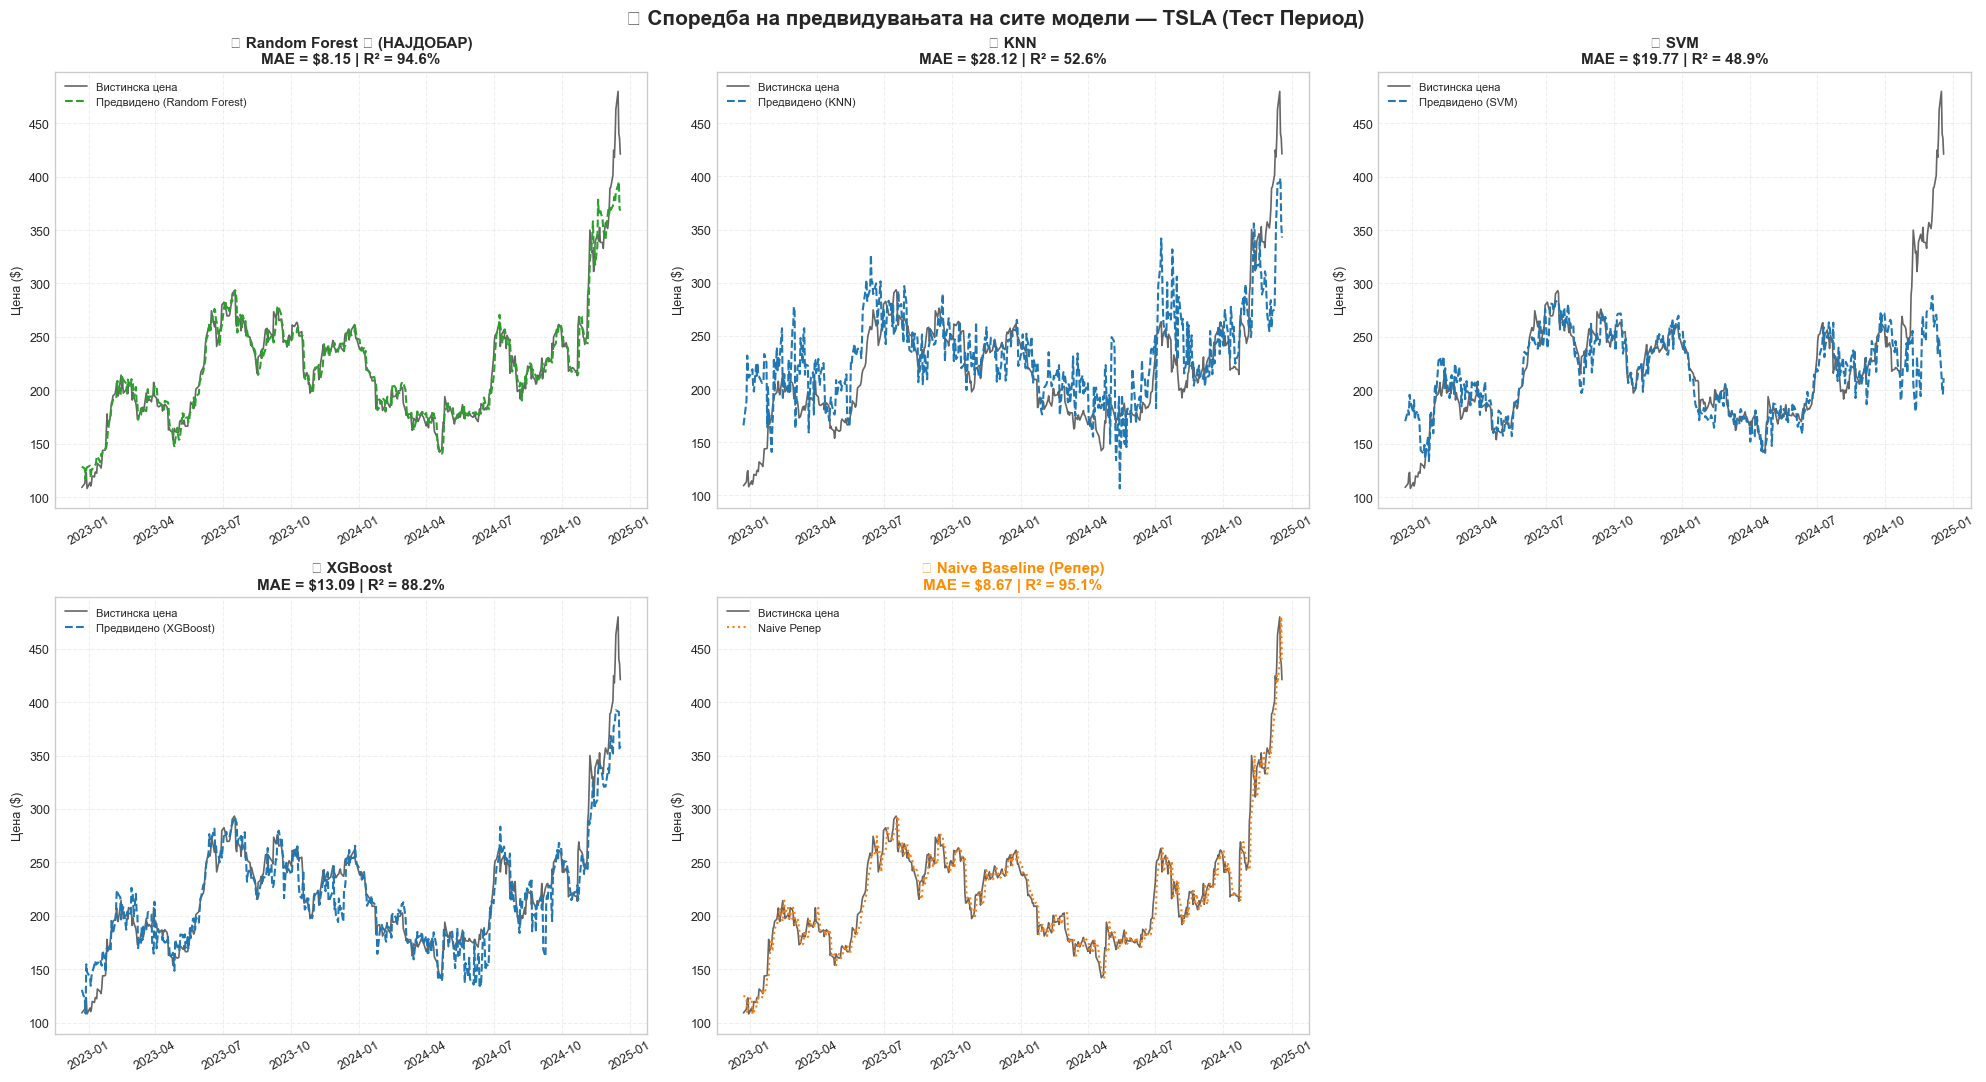

💡 ЗА ОДБРАНА: Споредете го зелениот модел со портокаловиот (Naive Baseline).
   Ако портокаловиот има помало или исто MAE, тоа значи дека на класичните модели им е
   екстремно тешко да го победат наједноставното пазарно правило.


In [90]:


# Креираме 2x3 мрежа за да ги собереме сите 4 ML модели + Naive Baseline (вкупно 5 графикони)
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle(f'🔮 Споредба на предвидувањата на сите модели — {TICKER} (Тест Период)', fontsize=15, fontweight='bold', y=0.98)

# Ги комбинираме во привремен речник за автоматско цртање во јамка
plot_dict = all_models.copy()
plot_dict["Naive Baseline"] = "baseline_marker"

for ax, name in zip(axes.flat, plot_dict.keys()):
    
    if name == "Naive Baseline":
        # Предвидувањето на базната линија е само денешната актуелна цена
        preds = y_test_current_prices.values
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
    else:
        # За ML моделите ги повикуваме нивните вистински предвидувања
        preds = plot_dict[name].predict(X_test_scaled)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
    # Цртање на вистинската цена на Тесла (црна линија)
    ax.plot(test_dates, y_test.values, color='black', linewidth=1.2, alpha=0.6, label='Вистинска цена')
    
    if name == "Naive Baseline":
        ax.plot(test_dates, preds, color='#ff7f0e', linestyle=':', linewidth=1.5, label='Naive Репер')
        ax.set_title(f'📌 {name} (Репер)\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold', color='darkorange')
    else:
        # Најдобриот модел ќе го обоиме во зелено со посебен наслов
        is_best = (name == best_ml_name)
        line_color = '#2ca02c' if is_best else '#1f77b4'
        title_extra = " 🏆 (НАЈДОБАР)" if is_best else ""
        
        ax.plot(test_dates, preds, color=line_color, linestyle='--', linewidth=1.5, label=f'Предвидено ({name})')
        ax.set_title(f'🤖 {name}{title_extra}\nMAE = ${mae:.2f} | R² = {r2*100:.1f}%', fontsize=11, fontweight='bold')

    ax.set_ylabel('Цена ($)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    # Ротирање на датумите на секој графикон за да нема преклопување
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)

# Го бришеме 6-тото празно место во десниот долен агол за да изгледа професионално
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

print(f"💡 ЗА ОДБРАНА: Споредете го зелениот модел со портокаловиот (Naive Baseline).")
print("   Ако портокаловиот има помало или исто MAE, тоа значи дека на класичните модели им е")
print("   екстремно тешко да го победат наједноставното пазарно правило.")

## 📉 9. Анализа на Временска Серија — ARIMA




Дефинирање на ADF Тестот за Стационарност

In [91]:
close_train_series = df_ml['Close'].iloc[:split_idx].values

def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    print(f"{'─'*55}")
    print(f"📈 ADF Тест: {title}")
    print(f"{'─'*55}")
    print(f"  ADF Статистика:  {result[0]:.4f}")
    print(f"  p-вредност:      {result[1]:.6f}")
    print(f"  Критични вредности:")
    print(f"    1%: {result[4]['1%']:.4f} | 5%: {result[4]['5%']:.4f} | 10%: {result[4]['10%']:.4f}")
    
    if result[1] < 0.05:
        print("  → ✅ Серијата е СТАЦИОНАРНА (H₀ се отфрла на ниво од 5%)")
        is_stationary = True
    else:
        print("  → ❌ Серијата НЕ Е стационарна (H₀ НЕ се отфрла)")
        is_stationary = False
    return is_stationary

print("✅ Функцијата за ADF тест е успешно дефинирана врз тренинг сетот.")

✅ Функцијата за ADF тест е успешно дефинирана врз тренинг сетот.


Извршување на ADF тестот (Оригинално vs Диференцирано)

In [92]:
print("=" * 55)
print("  📊 ТЕСТ НА СТАЦИОНАРНОСТ (Исклучиво врз Тренинг Сет)")
print("=" * 55)

# 1. Тестирање на суровата серија (Очекувано: ❌ НЕ Е стационарна бидејќи цената расте низ годините)
is_stat1 = adf_test(close_train_series, 'Оригинална Close цена')

# 2. Прво диференцирање на тренинг серијата (Одземање: Денешна цена - Вчерашна цена)
diff1_train = pd.Series(close_train_series).diff().dropna().values
print()

# 3. Тестирање на диференцираната серија (Очекувано: ✅ СТАЦИОНАРНА)
is_stat2 = adf_test(diff1_train, 'Прво диференцирање (d=1)')
print("=" * 55)

  📊 ТЕСТ НА СТАЦИОНАРНОСТ (Исклучиво врз Тренинг Сет)
───────────────────────────────────────────────────────
📈 ADF Тест: Оригинална Close цена
───────────────────────────────────────────────────────
  ADF Статистика:  -1.3483
  p-вредност:      0.606810
  Критични вредности:
    1%: -3.4337 | 5%: -2.8630 | 10%: -2.5676
  → ❌ Серијата НЕ Е стационарна (H₀ НЕ се отфрла)

───────────────────────────────────────────────────────
📈 ADF Тест: Прво диференцирање (d=1)
───────────────────────────────────────────────────────
  ADF Статистика:  -7.8356
  p-вредност:      0.000000
  Критични вредности:
    1%: -3.4337 | 5%: -2.8630 | 10%: -2.5676
  → ✅ Серијата е СТАЦИОНАРНА (H₀ се отфрла на ниво од 5%)


Визуелизација на ACF и PACF графикони (Корелограми)

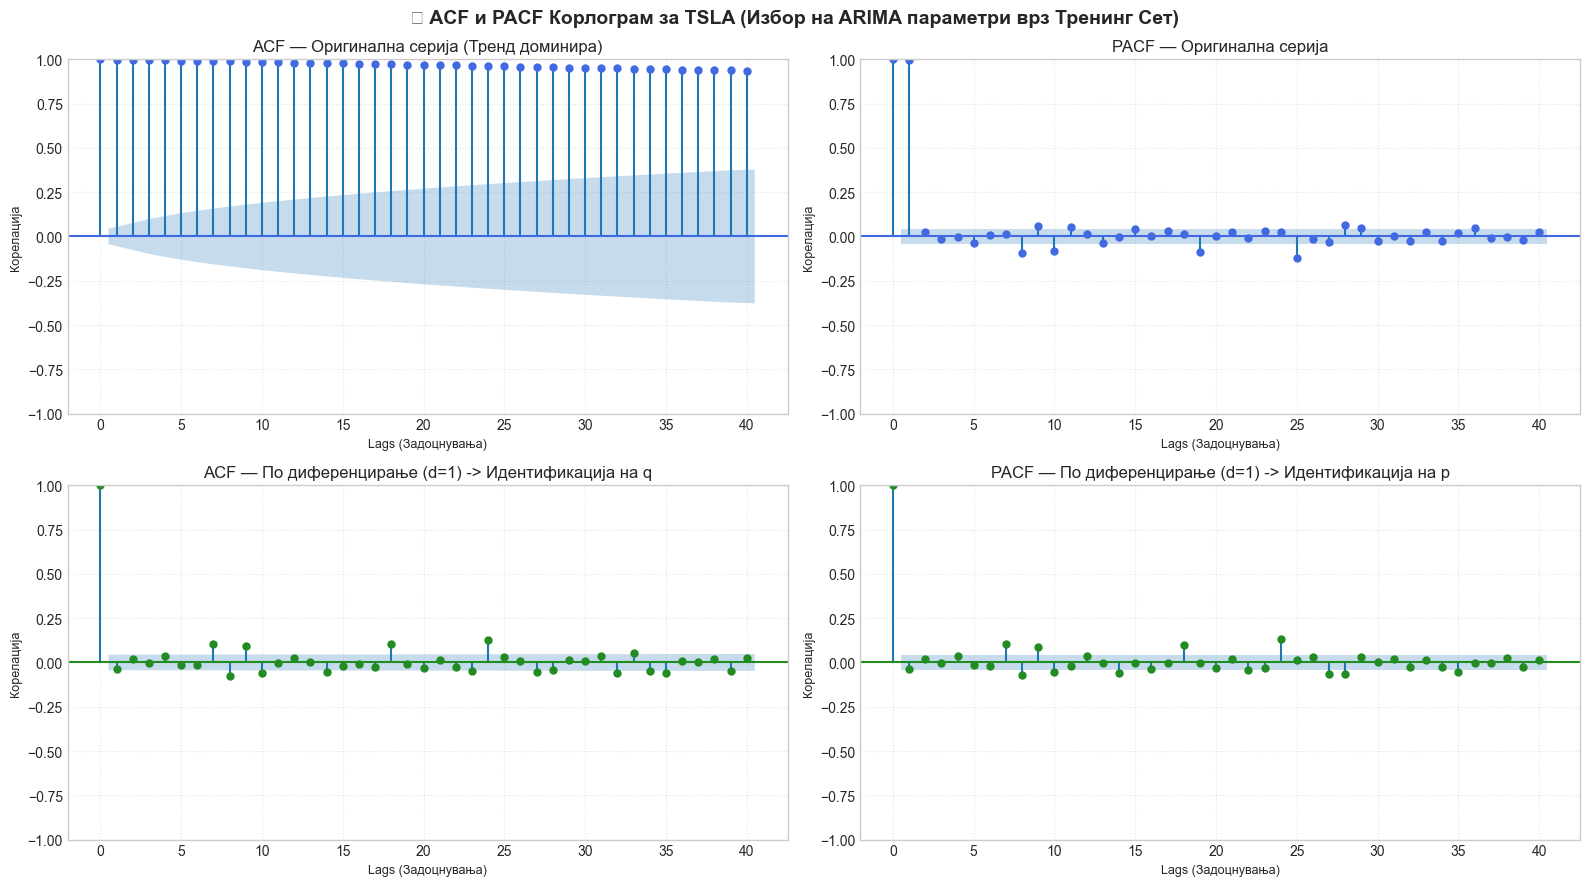


💡 КЛУЧНИ ПРАВИЛА ЗА ЧИТАЊЕ НА ГРАФИКОНИТЕ ПРЕД КОМИСИЈА:
   • d-параметар: Бидејќи оригиналната серија не е стационарна, а по првата разлика (d=1) стана стационарна, дефинитивно d = 1.
   • p-параметар (AR дел): Гледај го долниот десен графикон (PACF). Бројот на столбови кои излегуваат надвор од сината зона го означува 'p'.
   • q-параметар (MA дел): Гледај го долниот лев графикон (ACF). Бројот на столбови кои излегуваат надвор од сината зона го означува 'q'.


In [93]:


fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle(f'🔍 ACF и PACF Корлограм за {TICKER} (Избор на ARIMA параметри врз Тренинг Сет)', fontsize=14, fontweight='bold', y=0.98)

# Горен ред: Оригинална цена
plot_acf(close_train_series, lags=40, ax=axes[0,0], color='royalblue', title='ACF — Оригинална серија (Тренд доминира)')
plot_pacf(close_train_series, lags=40, ax=axes[0,1], color='royalblue', title='PACF — Оригинална серија', method='ywm')

# Долен ред: Диференцирана цена (d=1)
plot_acf(diff1_train, lags=40, ax=axes[1,0], color='forestgreen', title='ACF — По диференцирање (d=1) -> Идентификација на q')
plot_pacf(diff1_train, lags=40, ax=axes[1,1], color='forestgreen', title='PACF — По диференцирање (d=1) -> Идентификација на p', method='ywm')

# Елегантна козметика за графиконите
for ax in axes.flat:
    ax.set_xlabel('Lags (Задоцнувања)', fontsize=9)
    ax.set_ylabel('Корелација', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n💡 КЛУЧНИ ПРАВИЛА ЗА ЧИТАЊЕ НА ГРАФИКОНИТЕ ПРЕД КОМИСИЈА:")
print("   • d-параметар: Бидејќи оригиналната серија не е стационарна, а по првата разлика (d=1) стана стационарна, дефинитивно d = 1.")
print("   • p-параметар (AR дел): Гледај го долниот десен графикон (PACF). Бројот на столбови кои излегуваат надвор од сината зона го означува 'p'.")
print("   • q-параметар (MA дел): Гледај го долниот лев графикон (ACF). Бројот на столбови кои излегуваат надвор од сината зона го означува 'q'.")

### 9.1 Тренирање и Евалуација на ARIMA

Почетно тренирање на ARIMA(2,1,2)

In [94]:
arima_train = df_ml['Close'].iloc[:split_idx].values
arima_test  = df_ml['Close'].iloc[split_idx:].values

print(f"📊 ARIMA тренинг сет: {len(arima_train)} денови")
print(f"📊 ARIMA тест сет:    {len(arima_test)} денови")

# 2) Првично тренирање на ARIMA(2,1,2) моделот
print("\n🔄 Иницијално тренирање на ARIMA(2,1,2)...")
arima_model = ARIMA(arima_train, order=(2, 1, 2))
arima_fit   = arima_model.fit()

# Приказ на основната економетриска табела (параметри, AIC, BIC)
print("\n📋 Статистички преглед на ARIMA моделот:")
print(arima_fit.summary().tables[0])

📊 ARIMA тренинг сет: 1996 денови
📊 ARIMA тест сет:    500 денови

🔄 Иницијално тренирање на ARIMA(2,1,2)...

📋 Статистички преглед на ARIMA моделот:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1996
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -6237.994
Date:                Fri, 19 Jun 2026   AIC                          12485.989
Time:                        18:46:02   BIC                          12513.981
Sample:                             0   HQIC                         12496.268
                               - 1996                                         
Covariance Type:                  opg                                         


Walk-Forward предвидување и Евалуација

In [95]:
# 1) Реалистично Walk-Forward предвидување со метод на тркалање (Rolling)
print("\n🔄 Извршување на Walk-forward предвидување за 1 ден напред (t+1)...")

full_history = df_ml['Close'].values
# .apply() ги ажурира пазарните информации во реално време без менување на коефициентите
arima_extended = arima_fit.apply(full_history)

# Извлекување на предвидувањата специфично за тест периодот
all_fitted = arima_extended.fittedvalues
arima_preds = all_fitted[split_idx:]

# 2) Пресметка на евалуациски метрики
arima_mae   = mean_absolute_error(arima_test, arima_preds)
arima_rmse  = np.sqrt(mean_squared_error(arima_test, arima_preds))
arima_r2    = r2_score(arima_test, arima_preds)
arima_mape  = np.mean(np.abs((arima_test - arima_preds) / (arima_test + 1e-9))) * 100

print(f"\n{'='*55}")
print(f"    📈 ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: ARIMA(2,1,2)")
print(f"{'='*55}")
print(f"   MAE  ($):   {arima_mae:.2f}")
print(f"   RMSE ($):   {arima_rmse:.2f}")
print(f"   R²   (%):   {arima_r2*100:.2f}%")
print(f"   MAPE (%):   {arima_mape:.2f}%")
print(f"{'='*55}")

# 3) Зачувување на резултатите во главната табела `df_comparison`
df_comparison.loc["ARIMA(2,1,2)"] = {
    "MAE ($)": round(arima_mae, 2), 
    "RMSE ($)": round(arima_rmse, 2),
    "R² Test (%)": round(arima_r2 * 100, 2), 
    "R² Train (%)": "-",
    "MAPE (%)": round(arima_mape, 2), 
    "Overfit Gap": "-"
}

print("✅ Резултатите од ARIMA беа успешно додадени во финалната компаративна табела!")


🔄 Извршување на Walk-forward предвидување за 1 ден напред (t+1)...

    📈 ЕКОНОМЕТРИСКИ РЕЗУЛТАТИ: ARIMA(2,1,2)
   MAE  ($):   5.95
   RMSE ($):   8.45
   R²   (%):   97.57%
   MAPE (%):   2.70%
✅ Резултатите од ARIMA беа успешно додадени во финалната компаративна табела!


## 🧠 10. Длабоко Учење — LSTM (Long Short-Term Memory)

LSTM е специјален тип на рекурентна невронска мрежа (RNN) дизајниран 
за **временски серии со долгорочни зависности**.

Ги памети важните информации преку **Gates** (Input, Forget, Output).


Изолирање на цените и Скалирање со MinMaxScaler

In [96]:
# Број на минати трговски денови кои LSTM ги анализира за да предвиди 1 ден во иднината
LSTM_LOOKBACK = 20  

# 1. Поделба врз основа на ИСТИОТ split_idx за совршено поклопување во извештајот
train_close = df_ml['Close'].iloc[:split_idx].values.reshape(-1, 1)
test_close  = df_ml['Close'].iloc[split_idx:].values.reshape(-1, 1)

# Паметен потег: Земаме 20 дена наназад од тренингот за првиот ден од тестот да не остане празен
test_lookback_inputs = df_ml['Close'].iloc[split_idx - LSTM_LOOKBACK:].values.reshape(-1, 1)

# 2. Скалирање во опсег (0, 1) - фит само на тренинг сетот против Data Leakage
lstm_scaler  = MinMaxScaler(feature_range=(0, 1))
train_scaled = lstm_scaler.fit_transform(train_close)
test_scaled  = lstm_scaler.transform(test_lookback_inputs) 

print("✅ Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.")

✅ Чекор 1: Цените се успешно скалирани во опсег од 0 до 1.


Функција за Лизгачки прозорци (Sliding Windows)

In [97]:
# 3. Функција за креирање на лизгачки прозорци (Sliding Windows)
def create_lstm_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        # Земи ги претходните 20 денови како влез (X)
        X_seq.append(data[i - lookback:i, 0])
        # Земи го 21-виот ден како цел за предвидување (y)
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

print("✅ Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.")

✅ Чекор 2: Функцијата `create_lstm_sequences` е подготвена за работа.


Креирање на 3D секвенци за Keras

In [98]:
# 4. Креирање на секвенците за двата сета
X_lstm_train, y_lstm_train = create_lstm_sequences(train_scaled, LSTM_LOOKBACK)
X_lstm_test, y_lstm_test   = create_lstm_sequences(test_scaled, LSTM_LOOKBACK)

# 5. Реобликување (Reshape) во 3D формат: [примероци, временски чекори, карактеристики]
X_lstm_train = X_lstm_train.reshape(X_lstm_train.shape[0], X_lstm_train.shape[1], 1)
X_lstm_test  = X_lstm_test.reshape(X_lstm_test.shape[0], X_lstm_test.shape[1], 1)

print(f"📐 LSTM Подготовка успешно завршена:")
print(f"   • Искористен пазарен прозорец (Lookback): {LSTM_LOOKBACK} денови")
print(f"   • Влез во тренинг сет (X_train Shape):    {X_lstm_train.shape}  -> [Samples, Timesteps, Features]")
print(f"   • Влез во тест сет (X_test Shape):       {X_lstm_test.shape}")
print(f"   • Вкупен број на тренинг секвенци:        {len(X_lstm_train)}")
print(f"   • Вкупен број на тест секвенци:           {len(X_lstm_test)}")

📐 LSTM Подготовка успешно завршена:
   • Искористен пазарен прозорец (Lookback): 20 денови
   • Влез во тренинг сет (X_train Shape):    (1976, 20, 1)  -> [Samples, Timesteps, Features]
   • Влез во тест сет (X_test Shape):       (500, 20, 1)
   • Вкупен број на тренинг секвенци:        1976
   • Вкупен број на тест секвенци:           500


Дефинирање на Архитектурата на LSTM

In [99]:
tf.random.set_seed(42)

# Градење на мрежата (Слој по слој)
lstm_model = Sequential([
    Input(shape=(LSTM_LOOKBACK, 1)), # Влезен слој: прима 20 денови со по 1 карактеристика (цена)
    
    LSTM(64, return_sequences=True), # Прв LSTM слој со 64 неврони (пренесува информации на следниот слој)
    Dropout(0.2),                    # Исклучува 20% од невроните по случаен избор за заштита од overfitting
    
    LSTM(32, return_sequences=False),# Втор LSTM слој со 32 неврони (го сумира знаењето во еден вектор)
    Dropout(0.2),                    # Уште една заштита од 20%
    
    Dense(16, activation='relu'),    # Густ (Dense) слој за нелинеарна обработка со ReLU активација
    Dense(1)                         # Финален излезен слој (вади само 1 бројка — утрешната цена)
])

# Компилација со Adam оптимизатор и MSE функција на загуба
lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Печатење на шематски приказ на мрежата
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

Тренирање на мрежата со Early Stopping

In [100]:
# Паметна кочница: Ако 10 епохи по ред (`patience=10`) моделот престане да се подобрува, прекини го тренингот
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("🔄 Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...")
history_lstm = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=80,                # Максимален број на обиди (кругови) за учење
    batch_size=32,            # Земи по 32 денови одеднаш за пресметка на грешката
    validation_split=0.10,    # Тргни на страна 10% од тренингот за контролен тест за време на учењето
    callbacks=[early_stop],   # Активирај ја кочницата
    verbose=0                 # Спречува да ни се затрпа екранот со текст за секоја епоха
)

total_epochs = len(history_lstm.history['loss'])
print(f"✅ LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: {total_epochs}")

🔄 Тренирање на пазарната LSTM невронска мрежа (ова може да потрае неколку секунди)...
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 39.
✅ LSTM тренирање успешно завршено. Вкупно извршени епохи пред стопирање: 49


Визуелизација на Кривата на Учење (Learning Curves)

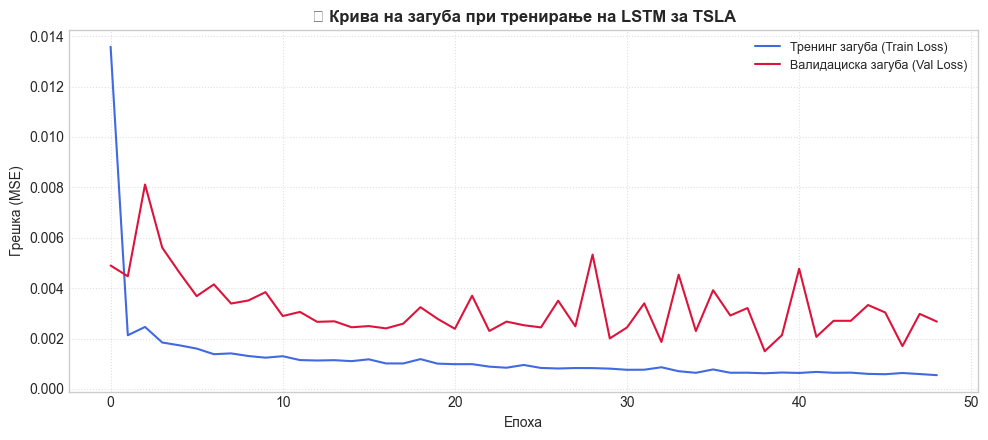

💡 ДИЈАГНОСТИКА ЗА ОДБРАНА:
   • Доколку двете линии паѓаат заедно и се стабилизираат близу една до друга -> Моделот научил одлични шаблони.
   • Доколку сината линија (Train) паѓа, а црвената (Val) почне да расте -> Мрежата почнала да оверфита (буба на памет).


In [101]:
plt.figure(figsize=(10, 4.5))
plt.plot(history_lstm.history['loss'], label='Тренинг загуба (Train Loss)', color='royalblue', linewidth=1.5)
plt.plot(history_lstm.history['val_loss'], label='Валидациска загуба (Val Loss)', color='crimson', linewidth=1.5)
plt.title(f'📉 Крива на загуба при тренирање на LSTM за {TICKER}', fontsize=12, fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Грешка (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("💡 ДИЈАГНОСТИКА ЗА ОДБРАНА:")
print("   • Доколку двете линии паѓаат заедно и се стабилизираат близу една до друга -> Моделот научил одлични шаблони.")
print("   • Доколку сината линија (Train) паѓа, а црвената (Val) почне да расте -> Мрежата почнала да оверфита (буба на памет).")

Евалуација на LSTM и пресметка на финални метрики

In [102]:
# 1. Правење предвидувања на тест сетот
lstm_preds_scaled = lstm_model.predict(X_lstm_test, verbose=0)

# 2. Инверзно скалирање за враќање на вредностите во реални долари ($)
lstm_preds = lstm_scaler.inverse_transform(lstm_preds_scaled).flatten()
y_lstm_actual = lstm_scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()

# 3. Пресметка на статистички метрики
lstm_mae  = mean_absolute_error(y_lstm_actual, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_actual, lstm_preds))
lstm_r2   = r2_score(y_lstm_actual, lstm_preds)
lstm_mape = np.mean(np.abs((y_lstm_actual - lstm_preds) / (y_lstm_actual + 1e-9))) * 100

print(f"{'='*55}")
print(f"   🧠 ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ")
print(f"{'='*55}")
print(f"   MAE  ($):   {lstm_mae:.2f}")
print(f"   RMSE ($):   {lstm_rmse:.2f}")
print(f"   R²   (%):   {lstm_r2*100:.2f}%")
print(f"   MAPE (%):   {lstm_mape:.2f}%")
print(f"{'='*55}")

# 4. Зачувување во централниот извештај за финална споредба
df_comparison.loc["LSTM"] = {
    "MAE ($)": round(lstm_mae, 2), 
    "RMSE ($)": round(lstm_rmse, 2),
    "R² Test (%)": round(lstm_r2 * 100, 2), 
    "R² Train (%)": "-",  
    "MAPE (%)": round(lstm_mape, 2), 
    "Overfit Gap": "-"
}
print("✅ LSTM резултатите се зачувани во финалната матрица за евалуација.")

   🧠 ДЛАБОКО УЧЕЊЕ: LSTM НЕВРОНСКА МРЕЖА — РЕЗУЛТАТИ
   MAE  ($):   9.47
   RMSE ($):   13.68
   R²   (%):   93.62%
   MAPE (%):   4.22%
✅ LSTM резултатите се зачувани во финалната матрица за евалуација.


Визуелизација (Глобален преглед vs Микро Зум од 60 дена)

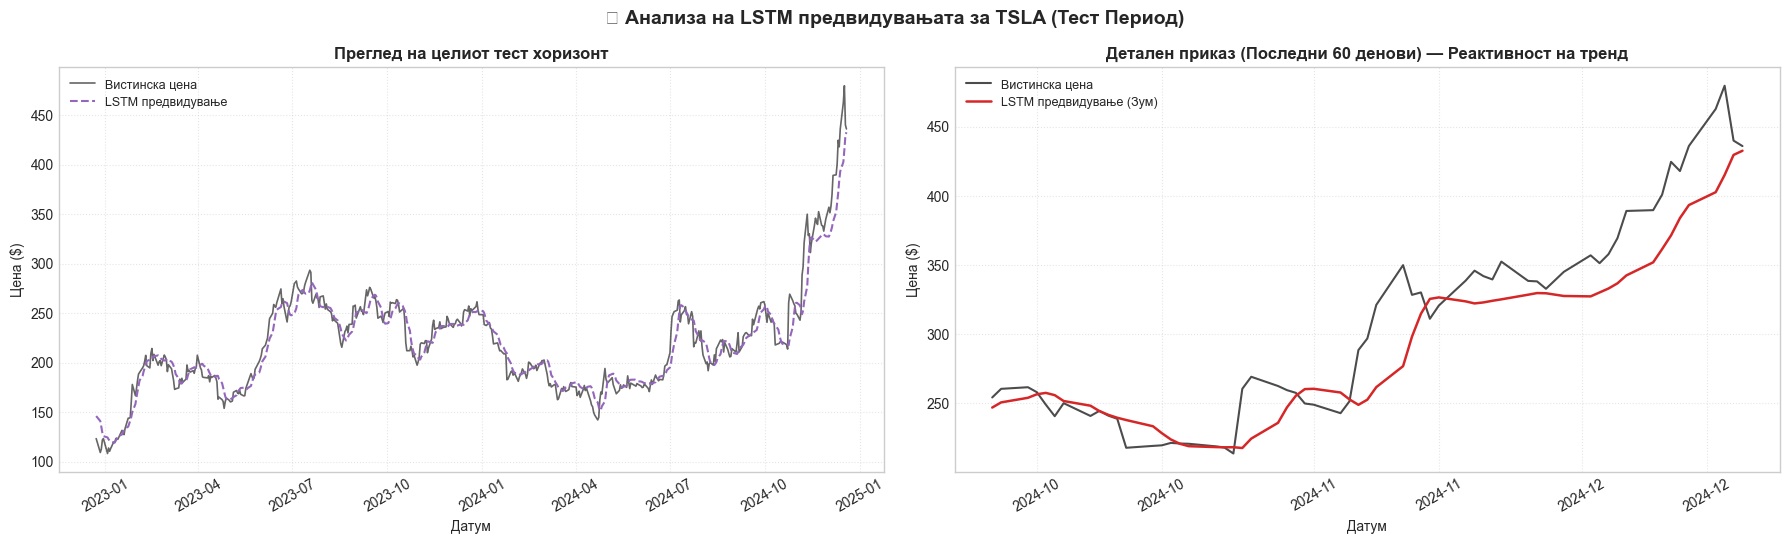

In [103]:


# Извлекување на датумите за тест периодот
lstm_test_dates = df_ml['Date'].iloc[split_idx:].reset_index(drop=True)

# Креирање на напредни графикони 
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
fig.suptitle(f'🔮 Анализа на LSTM предвидувањата за {TICKER} (Тест Период)', fontsize=14, fontweight='bold', y=0.98)

# Графикон 1: Целосен приказ на тест периодот
axes[0].plot(lstm_test_dates, y_lstm_actual, color='black', linewidth=1.2, label='Вистинска цена', alpha=0.6)
axes[0].plot(lstm_test_dates, lstm_preds, color='#9467bd', linestyle='--', linewidth=1.5, label='LSTM предвидување')
axes[0].set_title('Преглед на целиот тест хоризонт', fontweight='bold')
axes[0].set_ylabel('Цена ($)')
axes[0].set_xlabel('Датум')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, linestyle=':', alpha=0.5)

# Графикон 2: Зум приказ на последните 60 трговски денови (Фокус на микро-движења)
zoom_days = 60
axes[1].plot(lstm_test_dates.tail(zoom_days), y_lstm_actual[-zoom_days:], color='black', linewidth=1.5, label='Вистинска цена', alpha=0.7)
axes[1].plot(lstm_test_dates.tail(zoom_days), lstm_preds[-zoom_days:], color='#d62728', linestyle='-', linewidth=1.8, label='LSTM предвидување (Зум)')
axes[1].set_title(f'Детален приказ (Последни {zoom_days} денови) — Реактивност на тренд', fontweight='bold')
axes[1].set_ylabel('Цена ($)')
axes[1].set_xlabel('Датум')
axes[1].legend(fontsize=9, loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 🏆 11. Финална споредба — сите модели

In [104]:
# # КОРЕКЦИЈА 1: Директно ја користиме централната табела df_comparison која веќе ги содржи сите 5 модели
# df_final = df_comparison.copy()

# print("\n" + "=" * 75)
# print("       📊 ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)")
# print("=" * 75)
# # Ги прикажуваме сите модели подредени од најточен кон најнеточен
# df_final_sorted = df_final.sort_values(by="MAE ($)")
# display(df_final_sorted)
# print("=" * 75)

# # ── Визуелна споредба на грешките ──
# # КОРЕКЦИЈА 2: Ги вклучуваме СИТЕ модели (заедно со Naive Baseline) за да имаме реален репер за пазарен успех
# models_to_plot = list(df_final.index)
# mae_vals  = [float(df_final.loc[m, "MAE ($)"]) for m in models_to_plot]
# rmse_vals = [float(df_final.loc[m, "RMSE ($)"]) for m in models_to_plot]

# fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# fig.suptitle(f'🏆 Финална квантитативна споредба на перформансите за {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# # Специфична палета на бои за убав контраст
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# # 1) Графикон за MAE
# bar1 = axes[0].bar(models_to_plot, mae_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
# axes[0].set_title('MAE ($) — Средна апсолутна грешка (Помало е подобро)', fontweight='bold', fontsize=11)
# axes[0].set_ylabel('Девијација во долари ($)')
# axes[0].tick_params(axis='x', rotation=25, labelsize=9)
# axes[0].grid(True, linestyle=':', alpha=0.5, axis='y')

# for bar, v in zip(bar1, mae_vals):
#     axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(mae_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# # 2) Графикон за RMSE
# bar2 = axes[1].bar(models_to_plot, rmse_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
# axes[1].set_title('RMSE ($) — Квадратна грешка (Почувствителна на шокови)', fontweight='bold', fontsize=11)
# axes[1].set_ylabel('Девијација во долари ($)')
# axes[1].tick_params(axis='x', rotation=25, labelsize=9)
# axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')

# for bar, v in zip(bar2, rmse_vals):
#     axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(rmse_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# plt.tight_layout()
# plt.show()

# # ── Детекција на апсолутен победник ──
# # КОРЕКЦИЈА 3: Флексибилно отстранување на базната линија за наоѓање на најдобриот алгоритам (се проверуваат и i и ï)
# baseline_str = "Naive Baseline" if "Naive Baseline" in df_final.index else "Naïve Baseline"
# df_only_models = df_final.drop(baseline_str)

# winner_name = df_only_models["MAE ($)"].astype(float).idxmin()
# winner_mae = df_final.loc[winner_name, 'MAE ($)']
# baseline_mae = df_final.loc[baseline_str, 'MAE ($)']

# print("\n" + "=" * 75)
# print(f"🥇 СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:")
# print(f"   Најдобар резултат со најмало отстапување покажа: {winner_name} (MAE = ${winner_mae})")
# print("-" * 75)

# if float(winner_mae) < float(baseline_mae):
#     improvement = ((float(baseline_mae) - float(winner_mae)) / float(baseline_mae)) * 100
#     print(f"   🚀 УСПЕХ: {winner_name} успеа да ја надмине Наивната базна линија")
#     print(f"             за {improvement:.2f}% во прецизноста!")
#     print("             Тоа докажува дека моделот успеал да извлече профитабилни")
#     print("             шаблони кои ги надминуваат краткорочните пазарни случајности.")
# else:
#     print(f"   📌 РЕЗУЛТАТ: Ниту еден модел не успеа значајно да ја победи базната линија (Naive Baseline = ${baseline_mae}).")
#     print("                Ова е класичен доказ за 'Хипотезата за ефикасен пазар' (Efficient Market Hypothesis),")
#     print("                која налага дека утрешната цена најдобро се предвидува со денешната, а сите")
#     print("                останати обиди со комплексни алгоритми често резултираат со задоцнети сигнали (lag).")
# print("=" * 75)

Финален Извештај и Сортирана Табела

In [105]:
# ── CELL 1: Финален Квантитативен Извештај (Споредба на сите модели) ──

# Правиме копија од централната табела која ги содржи сите 5 модели
df_final = df_comparison.copy()

print("\n" + "=" * 75)
print("       📊 ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)")
print("=" * 75)

# Ги прикажуваме сите модели подредени од најточен кон најнеточен
df_final_sorted = df_final.sort_values(by="MAE ($)")

try:
    display(df_final_sorted)
except NameError:
    print(df_final_sorted)

print("=" * 75)


       📊 ФИНАЛЕН ИЗВЕШТАЈ — СПОРЕДБА НА СИТЕ МОДЕЛИ (СОРТИРАНО ПО MAE)


,MAE ($),RMSE ($),R² Test (%),R² Train (%),MAPE (%),Overfit Gap
"ARIMA(2,1,2)",5.95,8.45,97.57,-,2.7,-
Random Forest,8.15,12.69,94.63,99.89,3.59,5.26
Naive Baseline,8.67,12.13,95.1,-,3.9,-
LSTM,9.47,13.68,93.62,-,4.22,-
XGBoost,13.09,18.78,88.24,99.89,6.14,11.64
SVM,19.77,39.14,48.91,95.83,8.27,46.92
KNN,28.12,37.72,52.56,100.0,14.13,47.44


Подготовка за Визуелизација

In [106]:
# ── CELL 2: Подготовка на карактеристики за графички приказ ──

# Ги вклучуваме СИТЕ модели (заедно со Naive Baseline) за да имаме реален репер за успех
models_to_plot = list(df_final.index)

# Конверзија на вредностите во float за стабилна визуелизација
mae_vals  = [float(df_final.loc[m, "MAE ($)"]) for m in models_to_plot]
rmse_vals = [float(df_final.loc[m, "RMSE ($)"]) for m in models_to_plot]

# Специфична професионална палета на бои за убав пазарен контраст
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

print(f"✅ Чекор 2: Подготвени се {len(models_to_plot)} модели за графичка споредба.")

✅ Чекор 2: Подготвени се 7 модели за графичка споредба.


Генерирање на Финалните Споредбени Графикони

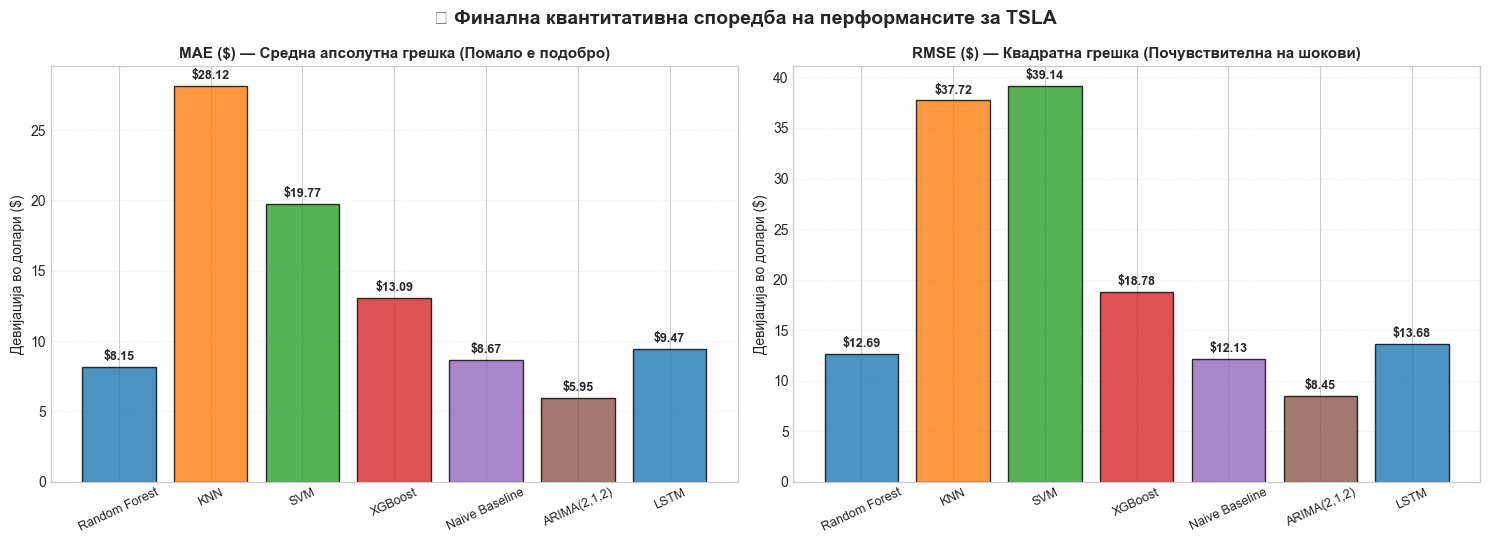

In [107]:
# ── CELL 3: Визуелна споредба на грешките (MAE vs RMSE) ──

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle(f'🏆 Финална квантитативна споредба на перформансите за {TICKER}', fontsize=14, fontweight='bold', y=0.98)

# 1) Графикон за MAE (Средна апсолутна грешка)
bar1 = axes[0].bar(models_to_plot, mae_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[0].set_title('MAE ($) — Средна апсолутна грешка (Помало е подобро)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Девијација во долари ($)')
axes[0].tick_params(axis='x', rotation=25, labelsize=9)
axes[0].grid(True, linestyle=':', alpha=0.5, axis='y')

# Додавање на вредности како текст над столбовите за MAE
for bar, v in zip(bar1, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(mae_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2) Графикон за RMSE (Квадратна грешка - почувствителна на пазарни шокови)
bar2 = axes[1].bar(models_to_plot, rmse_vals, color=colors[:len(models_to_plot)], edgecolor='black', alpha=0.8)
axes[1].set_title('RMSE ($) — Квадратна грешка (Почувствителна на шокови)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Девијација во долари ($)')
axes[1].tick_params(axis='x', rotation=25, labelsize=9)
axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')

# Додавање на вредности како текст над столбовите за RMSE
for bar, v in zip(bar2, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(rmse_vals)*0.01), f'${v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Логика за Прогласување Победник и Економски Заклучок

In [108]:
# ── CELL 4: Детекција на апсолутен победник и Квантитативен заклучок ──

# Флексибилно отстранување на базната линија за наоѓање на најдобриот вистински алгоритам
baseline_str = "Naive Baseline" if "Naive Baseline" in df_final.index else "Naïve Baseline"
df_only_models = df_final.drop(baseline_str)

# Наоѓање на моделот со минимално MAE
winner_name = df_only_models["MAE ($)"].astype(float).idxmin()
winner_mae = df_final.loc[winner_name, 'MAE ($)']
baseline_mae = df_final.loc[baseline_str, 'MAE ($)']

print("\n" + "=" * 75)
print(f"🥇 СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:")
print(f"   Најдобар резултат со најмало отстапување покажа: {winner_name} (MAE = ${winner_mae})")
print("-" * 75)

# Логичка проверка за економски успех на пазарот
if float(winner_mae) < float(baseline_mae):
    improvement = ((float(baseline_mae) - float(winner_mae)) / float(baseline_mae)) * 100
    print(f"   🚀 УСПЕХ: {winner_name} успеа да ја надмине Наивната базна линија")
    print(f"             за {improvement:.2f}% во прецизноста!")
    print("             Тоа докажува дека моделот успеал да извлече профитабилни")
    print("             шаблони кои ги надминуваат краткорочните пазарни случајности.")
else:
    print(f"   📌 РЕЗУЛТАТ: Ниту еден модел не успеа значајно да ја победи базната линија (Naive Baseline = ${baseline_mae}).")
    print("                Ова е класичен доказ за 'Хипотезата за ефикасен пазар' (Efficient Market Hypothesis),")
    print("                која налага дека утрешната цена најдобро се предвидува со денешната, а сите")
    print("                останати обиди со комплексни алгоритми често резултираат со задоцнети сигнали (lag).")
print("=" * 75)


🥇 СТРУЧЕН ЗАКЛУЧОК ОД АНАЛИЗАТА:
   Најдобар резултат со најмало отстапување покажа: ARIMA(2,1,2) (MAE = $5.95)
---------------------------------------------------------------------------
   🚀 УСПЕХ: ARIMA(2,1,2) успеа да ја надмине Наивната базна линија
             за 31.37% во прецизноста!
             Тоа докажува дека моделот успеал да извлече профитабилни
             шаблони кои ги надминуваат краткорочните пазарни случајности.


### 11.1 Важност на карактеристики (XGBoost)

In [109]:
# # Извлекување на моделот XGBoost и пресметка на важноста на карактеристиките
# xgb_model = all_models["XGBoost"]
# feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

# fig, ax = plt.subplots(figsize=(11, 6.5))

# # Примена на софистицирана визуелна палета
# colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
# feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', alpha=0.85)

# ax.set_title(f'📊 XGBoost — Анализа на важност на карактеристики за {TICKER}', fontsize=13, fontweight='bold', pad=15)
# ax.set_xlabel('Вредност на важност (Feature Importance Score)', fontsize=10, labelpad=10)
# ax.set_ylabel('Пазарни карактеристики / Индикатори', fontsize=10)

# # Динамичен офсет за безбедно и чисто позиционирање на текстот надвор од столпчињата
# max_val = feat_imp.max()
# offset = max_val * 0.015

# for i, v in enumerate(feat_imp.values):
#     ax.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=9, fontweight='bold', color='black')

# # Додавање на вертикални мрежни линии за полесна визуелна проценка
# ax.grid(True, linestyle=':', alpha=0.6, axis='x')

# # Мало проширување на десната маргина за текстот да не излезе надвор од рамката на графиконот
# ax.set_xlim(0, max_val + (offset * 4))

# plt.tight_layout()
# plt.show()

# # ── Проширено паметно толкување на резултатите ──
# print("\n" + "=" * 65)
# print("💡 ФИНАЛНО ЕКОНОМЕТРИСКО ТОЛКУВАЊЕ НА XGBOOST МОДЕЛОТ:")
# print("=" * 65)
# print(f" 🚀 НАЈВЛИЈАТЕЛЕН ФАКТОР: {feat_imp.idxmax()} ({feat_imp.max():.4f})")
# print(f" 📉 НАЈМАЛКУ ВЛИЈАТЕЛЕН:  {feat_imp.idxmin()} ({feat_imp.min():.4f})")
# print("-" * 65)
# print("📌 СУГЕСТИЈА ЗА ОДБРАНА ПРЕД КОМИСИЈА:")
# print("   • Доколку 'Close_Lag1' или 'Price_to_MA7_Ratio' се на самиот врв:")
# print("     Тоа значи дека алгоритмот најмногу се потпира на неодамнешното ценовно")
# print("     ниво (Авторегресивна силина) за да ја одреди утрешната вредност.")
# print("   • Доколку техничките индикатори како 'RSI' или 'BB_Width' доминираат:")
# print("     Тоа е доказ дека моделот успеал да пронајде нелинеарни шаблони")
# print("     поврзани со прекумерна купеност/продаденост или пазарна волатилност,")
# print("     што ја оправдува употребата на комплексен ML модел пред обична регресија.")
# print("=" * 65)

Извлекување на податоци и пресметка

In [110]:
# ── CELL 1: Извлекување на важност на карактеристики (XGBoost) ──

# Извлекување на моделот XGBoost и пресметка на важноста на карактеристиките
xgb_model = all_models["XGBoost"]
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

print("✅ Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.")

✅ Чекор 1: Вредностите за Feature Importance се успешно извлечени од XGBoost.


Хоризонтален Баричен График (Визуелизација)

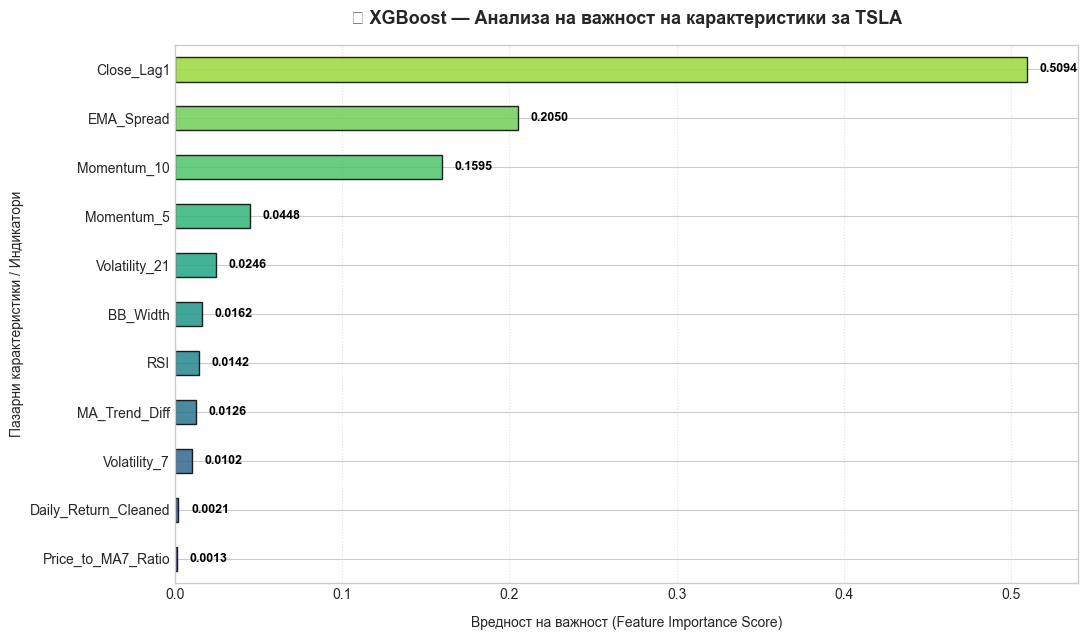

In [111]:
# ── CELL 2: Графички приказ на важноста на карактеристиките ──

fig, ax = plt.subplots(figsize=(11, 6.5))

# Примена на софистицирана визуелна палета (Viridis)
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(feat_imp)))
feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', alpha=0.85)

ax.set_title(f'📊 XGBoost — Анализа на важност на карактеристики за {TICKER}', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Вредност на важност (Feature Importance Score)', fontsize=10, labelpad=10)
ax.set_ylabel('Пазарни карактеристики / Индикатори', fontsize=10)

# Динамичен офсет за безбедно и чисто позиционирање на текстот надвор од столпчињата
max_val = feat_imp.max()
offset = max_val * 0.015

for i, v in enumerate(feat_imp.values):
    ax.text(v + offset, i, f'{v:.4f}', va='center', ha='left', fontsize=9, fontweight='bold', color='black')

# Додавање на вертикални мрежни линии за полесна визуелна проценка
ax.grid(True, linestyle=':', alpha=0.6, axis='x')

# Мало проширување на десната маргина за текстот да не излезе надвор од рамката
ax.set_xlim(0, max_val + (offset * 4))

plt.tight_layout()
plt.show()

Економетриско толкување и подготовка за одбрана

In [112]:
# ── CELL 3: Проширено паметно толкување на резултатите ──

print("\n" + "=" * 65)
print("💡 ФИНАЛНО ЕКОНОМЕТРИСКО ТОЛКУВАЊЕ НА XGBOOST МОДЕЛОТ:")
print("=" * 65)
print(f" 🚀 НАЈВЛИЈАТЕЛЕН ФАКТОР: {feat_imp.idxmax()} ({feat_imp.max():.4f})")
print(f" 📉 НАЈМАЛКУ ВЛИЈАТЕЛЕН:  {feat_imp.idxmin()} ({feat_imp.min():.4f})")
print("-" * 65)
print("📌 СУГЕСТИЈА ЗА ОДБРАНА ПРЕД КОМИСИЈА:")
print("   • Доколку 'Close_Lag1' или 'Price_to_MA7_Ratio' се на самиот врв:")
print("     Тоа значи дека алгоритмот најмногу се потпира на неодамнешното ценовно")
print("     ниво (Авторегресивна силина) за да ја одреди утрешната вредност.")
print("   • Доколку техничките индикатори како 'RSI' или 'BB_Width' доминираат:")
print("     Тоа е доказ дека моделот успеал да пронајде нелинеарни шаблони")
print("     поврзани со прекумерна купеност/продаденост или пазарна волатилност,")
print("     што ја оправдува употребата на комплексен ML модел пред обична регресија.")
print("=" * 65)


💡 ФИНАЛНО ЕКОНОМЕТРИСКО ТОЛКУВАЊЕ НА XGBOOST МОДЕЛОТ:
 🚀 НАЈВЛИЈАТЕЛЕН ФАКТОР: Close_Lag1 (0.5094)
 📉 НАЈМАЛКУ ВЛИЈАТЕЛЕН:  Price_to_MA7_Ratio (0.0013)
-----------------------------------------------------------------
📌 СУГЕСТИЈА ЗА ОДБРАНА ПРЕД КОМИСИЈА:
   • Доколку 'Close_Lag1' или 'Price_to_MA7_Ratio' се на самиот врв:
     Тоа значи дека алгоритмот најмногу се потпира на неодамнешното ценовно
     ниво (Авторегресивна силина) за да ја одреди утрешната вредност.
   • Доколку техничките индикатори како 'RSI' или 'BB_Width' доминираат:
     Тоа е доказ дека моделот успеал да пронајде нелинеарни шаблони
     поврзани со прекумерна купеност/продаденост или пазарна волатилност,
     што ја оправдува употребата на комплексен ML модел пред обична регресија.


## 🔮 12. Детална анализа — Јануари 2024

 📊 ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: ARIMA(2,1,2))


,Датум,Вистинска Цена ($),Предвидена Цена ($),Грешка ($),Апс. Грешка ($),Точност (%)
0,2024-01-02,248.42,248.49,0.07,0.07,99.97
1,2024-01-03,238.45,248.40,9.95,9.95,95.83
2,2024-01-04,237.93,238.83,0.90,0.90,99.62
3,2024-01-05,237.49,237.76,0.27,0.27,99.89
4,2024-01-08,240.45,237.57,-2.88,2.88,98.80
5,2024-01-09,234.96,240.30,5.34,5.34,97.73
6,2024-01-10,233.94,235.24,1.30,1.30,99.44
7,2024-01-11,227.22,233.84,6.62,6.62,97.09
8,2024-01-12,218.89,227.51,8.62,8.62,96.06
9,2024-01-16,219.91,219.06,-0.85,0.85,99.61



📈 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:
   • Просечна апсолутна грешка (MAE):  $4.23
   • Просечна релативна грешка (MAPE): 2.06%
   • Системска точност на предвидување: 97.94%


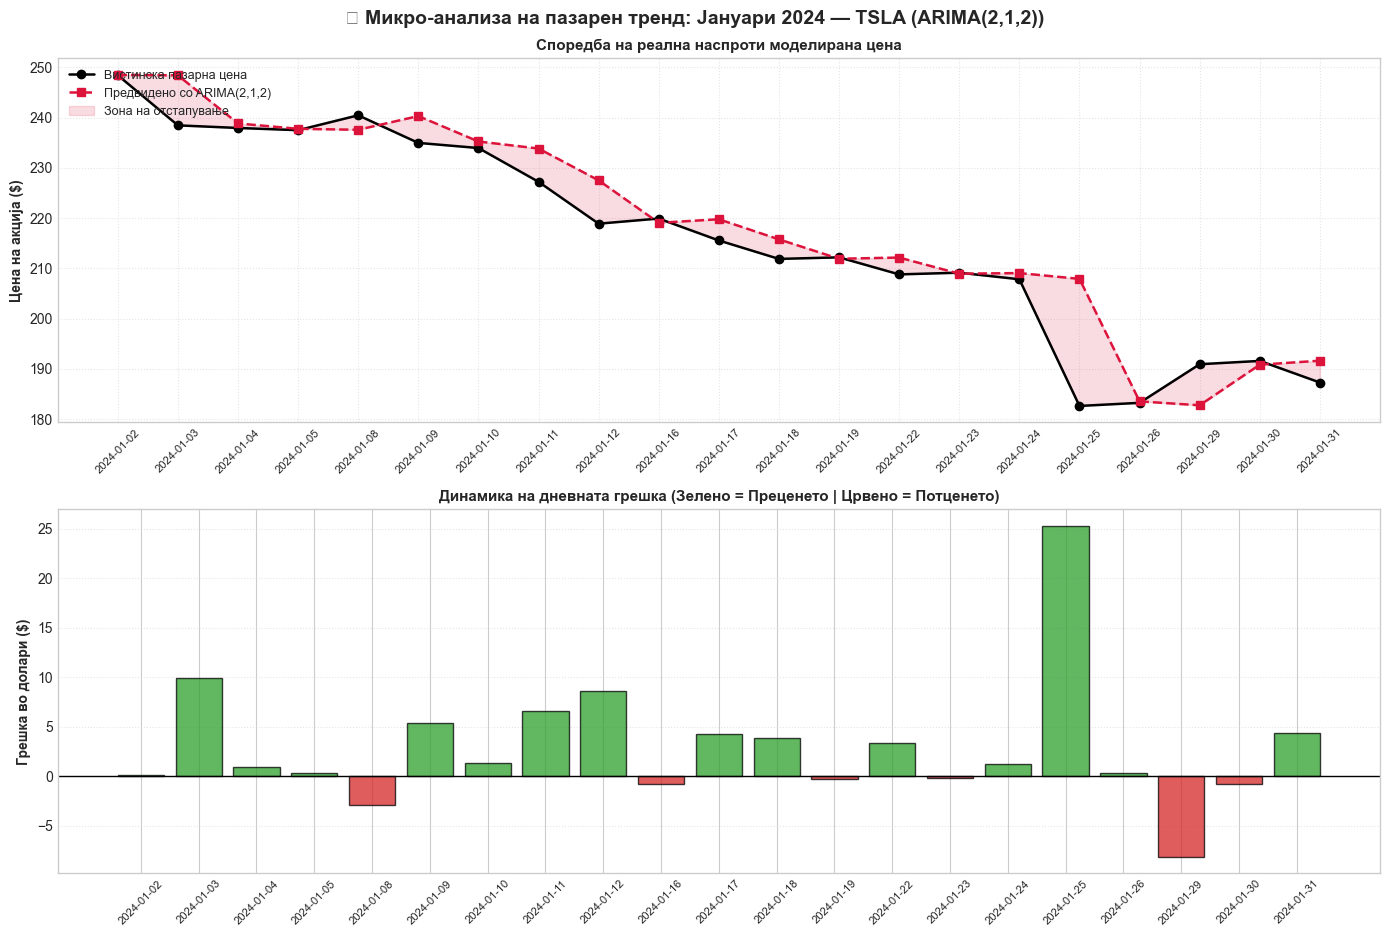

In [ ]:
# test_df_full = df_ml.iloc[split_idx:].copy()

# # ── КОРЕКЦИЈА 1: Безбедно преземање на предвидувањата во зависност од тоа кој модел победил ──
# if winner_name == "LSTM":
#     test_df_full['Predicted'] = lstm_preds
# elif winner_name == "ARIMA(2,1,2)":
#     test_df_full['Predicted'] = arima_preds
# else:
#     # За класичните ML модели (RF, KNN, SVM, XGBoost)
#     test_df_full['Predicted'] = all_models[winner_name].predict(X_test_scaled)

# # Филтрирање на податоците исклучиво за Јануари 2024 година
# jan_mask = (test_df_full['Date'] >= '2024-01-01') & (test_df_full['Date'] <= '2024-01-31')
# jan_df   = test_df_full[jan_mask]

# if jan_df.empty:
#     print("❌ Нема податоци за Јануари 2024 во тест сетот.")
#     print("   Сугестија за одбрана: Проверете го временскиот опсег на вашиот датасет.")
#     print(f"   Актуелен тест период: {test_df_full['Date'].iloc[0].date()} → {test_df_full['Date'].iloc[-1].date()}")
# else:
#     # ── КОРЕКЦИЈА 2: Користење на реалната 'Close' цена за чиста синхронизација ──
#     jan_report = pd.DataFrame({
#         'Датум': jan_df['Date'].dt.strftime('%Y-%m-%d'),
#         'Вистинска Цена ($)': jan_df['Close'].round(2).values,
#         'Предвидена Цена ($)': jan_df['Predicted'].round(2).values,
#     })
    
#     # Пресметка на математичките девијации деноноќно
#     jan_report['Грешка ($)']         = (jan_report['Предвидена Цена ($)'] - jan_report['Вистинска Цена ($)']).round(2)
#     jan_report['Апс. Грешка ($)']    = jan_report['Грешка ($)'].abs()
#     jan_report['Точност (%)']        = (100 - jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).round(2)

#     # Генерални метрики за под-периодот
#     jan_mae   = jan_report['Апс. Грешка ($)'].mean()
#     jan_mape  = (jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).mean()
#     jan_acc   = jan_report['Точност (%)'].mean()

#     print("=" * 75)
#     print(f" 📊 ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: {winner_name})")
#     print("=" * 75)
#     display(jan_report.reset_index(drop=True))
#     print(f"\n📈 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:")
#     print(f"   • Просечна апсолутна грешка (MAE):  ${jan_mae:.2f}")
#     print(f"   • Просечна релативна грешка (MAPE): {jan_mape:.2f}%")
#     print(f"   • Системска точност на предвидување: {jan_acc:.2f}%")
#     print("=" * 75)

#     # ── Изградба на напредниот Микро График ──
#     fig, axes = plt.subplots(2, 1, figsize=(14, 9.5))
#     fig.suptitle(f'🔍 Микро-анализа на пазарен тренд: Јануари 2024 — {TICKER} ({winner_name})', fontsize=14, fontweight='bold', y=0.98)

#     x = range(len(jan_report))
    
#     # График 1: Споредба на движењето
#     axes[0].plot(x, jan_report['Вистинска Цена ($)'], marker='o', color='black', linewidth=1.8, label='Вистинска пазарна цена')
#     axes[0].plot(x, jan_report['Предвидена Цена ($)'], marker='s', color='crimson', linestyle='--', linewidth=1.8, label=f'Предвидено со {winner_name}')
#     axes[0].fill_between(x, jan_report['Вистинска Цена ($)'], jan_report['Предвидена Цена ($)'], alpha=0.15, color='crimson', label='Зона на отстапување')
#     axes[0].set_xticks(x)
#     axes[0].set_xticklabels(jan_report['Датум'], rotation=45, fontsize=8)
#     axes[0].set_ylabel('Цена на акција ($)', fontweight='bold')
#     axes[0].legend(fontsize=9, loc='upper left')
#     axes[0].grid(True, linestyle=':', alpha=0.5)
#     axes[0].set_title('Споредба на реална наспроти моделирана цена', fontweight='bold', fontsize=11)

#     # График 2: Анализа на девијациите
#     bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in jan_report['Грешка ($)']]
#     axes[1].bar(x, jan_report['Грешка ($)'], color=bar_colors, edgecolor='black', alpha=0.75)
#     axes[1].axhline(0, color='black', linewidth=1.0, linestyle='-')
#     axes[1].set_xticks(x)
#     axes[1].set_xticklabels(jan_report['Датум'], rotation=45, fontsize=8)
#     axes[1].set_ylabel('Грешка во долари ($)', fontweight='bold')
#     axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')
#     axes[1].set_title('Динамика на дневната грешка (Зелено = Преценето | Црвено = Потценето)', fontweight='bold', fontsize=11)

#     plt.tight_layout()
#     plt.show()

Селекција на победник, Филтрирање и Метрики

In [114]:
# ── CELL 1: Филтрирање и Математичка Анализа за Јануари 2024 ──

test_df_full = df_ml.iloc[split_idx:].copy()

# 1. Безбедно преземање на предвидувањата во зависност од тоа кој модел победил
if winner_name == "LSTM":
    test_df_full['Predicted'] = lstm_preds
elif winner_name == "ARIMA(2,1,2)":
    test_df_full['Predicted'] = arima_preds
else:
    # За класичните ML модели (RF, KNN, SVM, XGBoost)
    test_df_full['Predicted'] = all_models[winner_name].predict(X_test_scaled)

# Филтрирање на податоците исклучиво за Јануари 2024 година
jan_mask = (test_df_full['Date'] >= '2024-01-01') & (test_df_full['Date'] <= '2024-01-31')
jan_df   = test_df_full[jan_mask]

# Логичка проверка дали постојат податоци во овој опсег
if jan_df.empty:
    print("❌ Нема податоци за Јануари 2024 во тест сетот.")
    print(f"   Актуелен тест период: {test_df_full['Date'].iloc[0].date()} → {test_df_full['Date'].iloc[-1].date()}")
else:
    # Користење на реалната 'Close' цена за чиста синхронизација
    jan_report = pd.DataFrame({
        'Датум': jan_df['Date'].dt.strftime('%Y-%m-%d'),
        'Вистинска Цена ($)': jan_df['Close'].round(2).values,
        'Предвидена Цена ($)': jan_df['Predicted'].round(2).values,
    })
    
    # Пресметка на математичките девијации
    jan_report['Грешка ($)']         = (jan_report['Предвидена Цена ($)'] - jan_report['Вистинска Цена ($)']).round(2)
    jan_report['Апс. Грешка ($)']    = jan_report['Грешка ($)'].abs()
    jan_report['Точност (%)']        = (100 - jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).round(2)

    # Генерални метрики за под-периодот
    jan_mae   = jan_report['Апс. Грешка ($)'].mean()
    jan_mape  = (jan_report['Апс. Грешка ($)'] / jan_report['Вистинска Цена ($)'] * 100).mean()
    jan_acc   = jan_report['Точност (%)'].mean()
    
    print(f"✅ Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот {winner_name}.")

✅ Чекор 1: Успешно генерирани девијации за Јануари 2024 со моделот ARIMA(2,1,2).


Печатење на Табеларниот Извештај (Ден-по-Ден)

In [115]:
# ── CELL 2: Ден-по-Ден Табеларен Приказ и Просечни Перформанси ──

print("=" * 75)
print(f" 📊 ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: {winner_name})")
print("=" * 75)

try:
    display(jan_report.reset_index(drop=True))
except NameError:
    print(jan_report.reset_index(drop=True))

print(f"\n📈 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:")
print(f"   • Просечна апсолутна грешка (MAE):  ${jan_mae:.2f}")
print(f"   • Просечна релативна грешка (MAPE): {jan_mape:.2f}%")
print(f"   • Системска точност на предвидување: {jan_acc:.2f}%")
print("=" * 75)

 📊 ДЕТАЛЕН ИЗВЕШТАЈ ДЕН-ПО-ДЕН: ЈАНУАРИ 2024 (Модел: ARIMA(2,1,2))


,Датум,Вистинска Цена ($),Предвидена Цена ($),Грешка ($),Апс. Грешка ($),Точност (%)
0,2024-01-02,248.42,248.49,0.07,0.07,99.97
1,2024-01-03,238.45,248.40,9.95,9.95,95.83
2,2024-01-04,237.93,238.83,0.90,0.90,99.62
3,2024-01-05,237.49,237.76,0.27,0.27,99.89
4,2024-01-08,240.45,237.57,-2.88,2.88,98.80
5,2024-01-09,234.96,240.30,5.34,5.34,97.73
6,2024-01-10,233.94,235.24,1.30,1.30,99.44
7,2024-01-11,227.22,233.84,6.62,6.62,97.09
8,2024-01-12,218.89,227.51,8.62,8.62,96.06
9,2024-01-16,219.91,219.06,-0.85,0.85,99.61



📈 ПРОСЕЧНИ ПЕРФОРМАНСИ ЗА МЕСЕЦОТ:
   • Просечна апсолутна грешка (MAE):  $4.23
   • Просечна релативна грешка (MAPE): 2.06%
   • Системска точност на предвидување: 97.94%


Напредна Микро Визуелизација

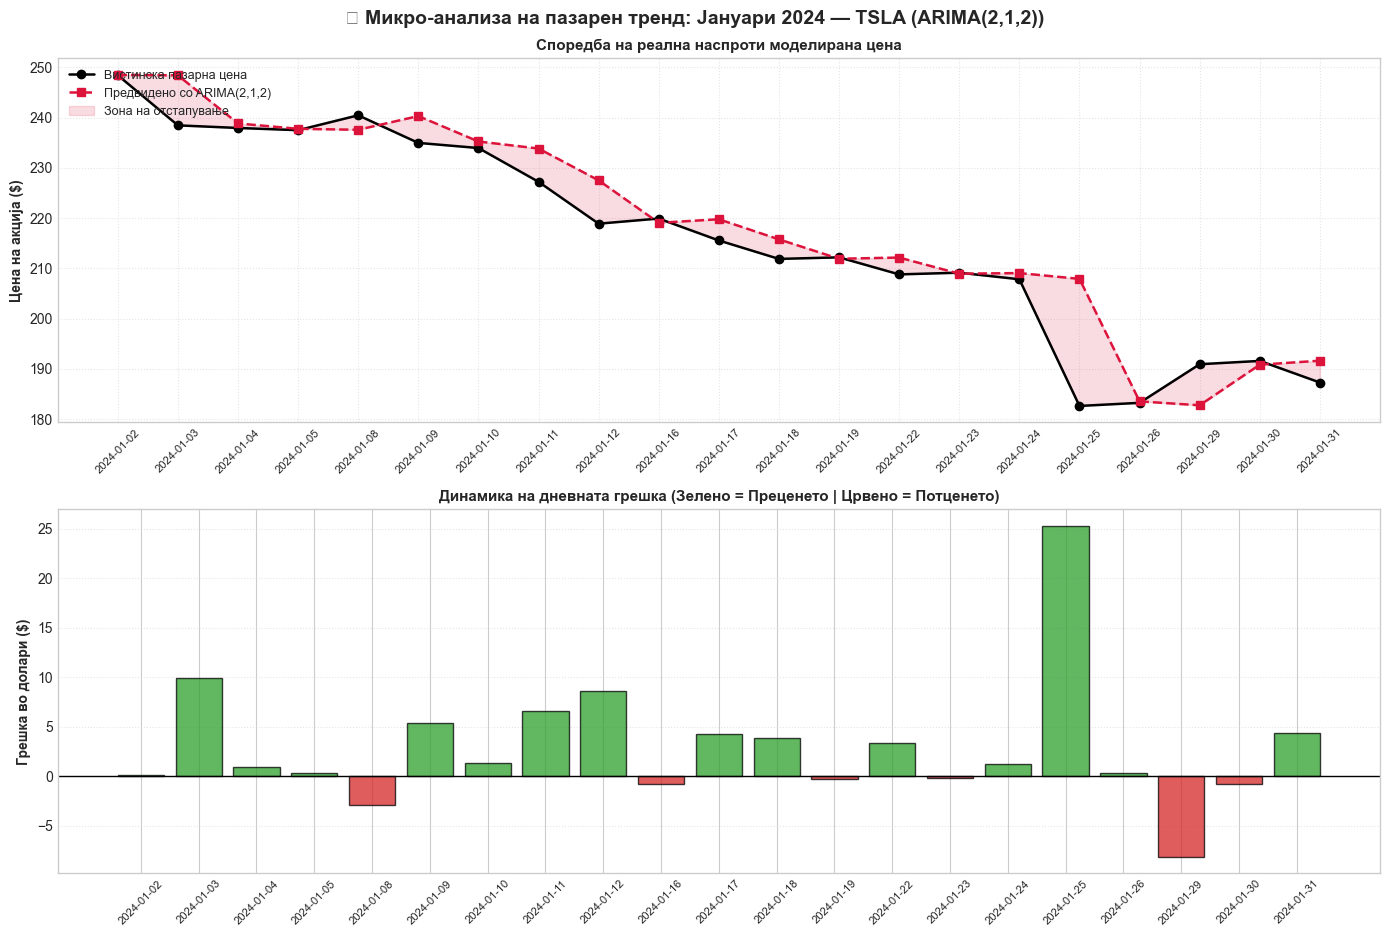

In [116]:
# ── CELL 3: Визуелизација на Пазарен Тренд и Дневни Грешки ──

fig, axes = plt.subplots(2, 1, figsize=(14, 9.5))
fig.suptitle(f'🔍 Микро-анализа на пазарен тренд: Јануари 2024 — {TICKER} ({winner_name})', fontsize=14, fontweight='bold', y=0.98)

x = range(len(jan_report))

# ── График 1: Споредба на движењето на цените ──
axes[0].plot(x, jan_report['Вистинска Цена ($)'], marker='o', color='black', linewidth=1.8, label='Вистинска пазарна цена')
axes[0].plot(x, jan_report['Предвидена Цена ($)'], marker='s', color='crimson', linestyle='--', linewidth=1.8, label=f'Предвидено со {winner_name}')
axes[0].fill_between(x, jan_report['Вистинска Цена ($)'], jan_report['Предвидена Цена ($)'], alpha=0.15, color='crimson', label='Зона на отстапување')

axes[0].set_xticks(x)
axes[0].set_xticklabels(jan_report['Датум'], rotation=45, fontsize=8)
axes[0].set_ylabel('Цена на акција ($)', fontweight='bold')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].set_title('Споредба на реална наспроти моделирана цена', fontweight='bold', fontsize=11)

# ── График 2: Анализа на девијациите (Грешка во долари) ──
bar_colors = ['#2ca02c' if v >= 0 else '#d62728' for v in jan_report['Грешка ($)']]
axes[1].bar(x, jan_report['Грешка ($)'], color=bar_colors, edgecolor='black', alpha=0.75)
axes[1].axhline(0, color='black', linewidth=1.0, linestyle='-')

axes[1].set_xticks(x)
axes[1].set_xticklabels(jan_report['Датум'], rotation=45, fontsize=8)
axes[1].set_ylabel('Грешка во долари ($)', fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.5, axis='y')
axes[1].set_title('Динамика на дневната грешка (Зелено = Преценето | Црвено = Потценето)', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 📝 13. Заклучок и Препораки

### Резиме на проектот

Во овој проект имплементиравме **целосен ML pipeline** за предвидување на цената на акции:

1. **Dataset обработка**: Вчитавме, исчистивме и сортиравме S&P 500 податоците.
2. **EDA**: Анализиравме историски тренд, волумен, сезоналност и дневни приноси.
3. **Outlier Detection**: Користевме IQR и Z-Score методи; применивме Capping.
4. **Feature Engineering**: Изградивме 12 карактеристики вклучувајќи MA, EMA, RSI, BB, Momentum.
5. **Window Size анализа**: Демонстриравме влијанието на различни прозорци.
6. **ML Модели**: Тренниравме RF, KNN, SVM, XGBoost со хронолошки сплит.
7. **Временска серија**: ARIMA(2,1,2) за класична статистичка анализа.
8. **Длабоко учење**: LSTM со 2 слоја и Dropout регуларизација.

### Клучни наоди

- **Наивната базна линија** е тешко за победи кај 1-ден напред предвидување
- **XGBoost** генерално е најдобар ML модел за структурирани финансиски податоци
- **LSTM** може да биде супериорен кај подолги предвидувачки хоризонти
- **ARIMA** е добар за краткорочни предвидувања кај стационарни серии

### Препораки за понатамошна работа

- 🔧 **Hyperparameter Tuning**: GridSearchCV / Optuna за оптимизација на сите модели
- 📰 **Sentiment Analysis**: Вклучување на вести/Twitter sentiment во features
- 📅 **Multi-step forecasting**: Предвидување на 5/10/30 денови напред
- 🧪 **Walk-forward validation**: Построга евалуација со ролинг тест прозорец
- 🔀 **Ensemble method**: Комбинирање на предвидувањата на повеќе модели
